<a id="top"></a>
<div style="padding:30px 34px;background:#123047;color:white;border-radius:12px">
<p style="color:#83d9c4;letter-spacing:2px;font-size:13px">BIOLOGY × MATHEMATICS · A RESEARCH TEACHING NOTEBOOK</p>
<h1 style="color:white;font-size:34px;line-height:1.15">Learning biological age:<br>metabolic clocks, fair explanations, and a new frontier for biology and mathematics</h1>
<p style="font-size:19px;color:#e4eef3">What can a machine learn about aging from a drop of serum, and how can we trust what it tells us?</p>
<p style="color:#e4eef3">Master's course · doctoral course · interdisciplinary colloquium</p>
</div>

This notebook brings **geneticists, metabolomics researchers, clinicians and mathematicians** into the same conversation. It follows one path: the problem and the challenge → the mathematical formulation → the mathematical goals → mathematics in action → the results achieved → interpretation for practitioners → take-home messages and research perspectives.

**The two papers behind this lecture**

- **[P1]** A. Ibáñez de Opakua, M. Bizkarguenaga, …, U. Biccari, R. Morales, …, E. Zuazua, J. M. Mato, Ó. Millet (multi-centre consortium), *Mapping metabolic aging and disease-associated acceleration using an interpretable NMR-based clock*.
- **[P2]** U. Biccari, A. Ibáñez de Opakua, J. M. Mato, Ó. Millet, R. Morales, E. Zuazua, *Fair feature attribution for multi-output prediction: a Shapley-based perspective*. [Manuscript PDF](https://arxiv.org/abs/2602.22882).

Both papers share mathematical co-authors (DeustoTech–University of Deusto, FAU Erlangen-Nürnberg, Universidad Autónoma de Madrid) and biomedical co-authors (CIC bioGUNE, ATLAS Molecular Pharma, CIBERehd). The joint venture this notebook describes already exists. Page, figure and theorem numbers refer to the manuscript versions linked above (keep this file next to the two PDFs so that the links work). Preparation date: 29 September 2026.


<div style="border-left:6px solid #9a6a12;background:#fbf4e6;color:#1d3540;padding:12px 20px;border-radius:8px;margin:16px 0">

<span style="color:#9a6a12;font-weight:700;letter-spacing:1.5px;font-size:12px">OPPORTUNITY</span> **The central message**

One routine serum NMR measurement can be turned into an **interpretable map** of how a person's metabolism ages, and of how each disease distorts that path. Making this map reliable, transportable and explainable is a problem that needs **geneticists and mathematicians working together**, and both papers show that the problem is already yielding results.

</div>

<div style="border-left:6px solid #9a6a12;background:#fbf4e6;color:#1d3540;padding:12px 20px;border-radius:8px;margin:16px 0">

<span style="color:#9a6a12;font-weight:700;letter-spacing:1.5px;font-size:12px">OPPORTUNITY</span> **Opportunities at a glance**

1. **A scalable molecular readout.** One serum sample, measured with a standard set of NMR experiments, yields 49 quantified metabolites and 25 NMR-inferred clinical biomarkers. P1 builds on a reference resource of **29,390 people aged 7–106** and **3,882 patients in 11 disease cohorts**. NMR is reproducible, needs minimal sample preparation and suits large epidemiological studies. [P1, pp. 2–5]
2. **Interpretability at a small price.** Binned spectra predict age best (r = 0.93, RMSE 6.5 y) but are numerically ill-conditioned (condition number κ ≈ 15,000). The curated biomarker clock keeps r = 0.88 (RMSE 8.7 y) with κ ≈ 16, gives stable SHAP profiles, and P1 reports less regression to the mean than earlier NMR clocks. The flattening that remains is predicted by a theorem (slope = R² for an optimal clock, section 3) and is removed by the reference line. [P1, pp. 2, 4–5]
3. **Disease maps, not a single number.** All 11 disease cohorts are shifted toward older metabolic profiles, from about 2.8 y (long COVID) to 17.5 y (influenza), while internal and external controls stay at baseline. The diseases separate along renal, inflammatory and strictly metabolic axes. [P1, pp. 7–11, Fig. 4]
4. **Early warning and plasticity.** People who later had a cardiovascular event already showed about 8 y of metabolic acceleration. IBD patients in remission showed about 3 y less distortion than patients with active disease. [P1, pp. 8, 11]
5. **A theorem that frees the modeller.** The rigidity theorem shows that any multi-output attribution obeying the classical Shapley axioms, imposed verbatim in $\mathbb R^m$, must be coordinate-wise. So a shared model, which in P2's experiment trained 2.79× faster than three separate models, can still be explained output by output, with feature-importance cosine similarity ≥ 0.974 to the separate models (an empirical finding). [P2, Thms 2.8–2.9, Tables 3–4]
6. **Open problems for both communities:** dynamic SHAP linked to control theory, Pareto structure of joint training, correlation-aware estimators, multi-omics integration, longitudinal and diverse cohorts. [P1, p. 11; P2, §4]

*Scope in one line:* these are associations in a predominantly Caucasian reference population; prospective individual utility is the next test. The evidence labels below mark what is reported, synthetic or proposed.

</div>

<a id="howto"></a>
## 0 · How to use this notebook

**Prerequisites.** Basic linear algebra, probability and regression, and familiarity with biological measurements. Python helps for the laboratory route but is not needed for the lecture route. A [two-way dictionary](#dictionary) translates terms in both directions.

**Learning objectives.** By the end you should be able to: distinguish age prediction from biological validity; explain why even the best possible clock has an age-dependent gap; design a leakage-resistant evaluation; diagnose correlated-feature instability; compute an exact Shapley allocation; state and use the rigidity theorem for multi-output explanations; read P1's disease maps; and formulate a research question shared by both communities.

| Route | Sections and activity | Suggested time |
|---|---|---:|
| Colloquium | Opportunities panel → 1 → 2 → 3 (formulation boxes) → videos 1–2 → rigidity theorem, interactive window and video 3 → 10 results (P1 figures, disease map, P2 results) → 11 practitioner table → 12 take-home → 13 perspectives. About 15 stops (41 cells), tagged `colloquium`. | 45–50 min + discussion |
| Master's lecture | All core text; predict each experiment before running it; discussion case in 11 | 90–120 min |
| Doctoral workshop | Full notebook, including the proofs, exact SHAP code and exercises in 14 | 3–4 h |

Colloquium stops carry the cell tag `colloquium`; `Bioage_Colloquium.html` is a code-free edition that contains only these stops. In JupyterLab the Table of Contents sidebar also works for navigation.

**Navigation:** [Problem](#problem) · [Challenge](#challenge) · [Formulation](#formulation) · [Goals](#goals) · [Clock lab](#clocklab) · [Age gaps & uncertainty](#calibration) · [Collinearity](#collinearity) · [SHAP](#shap) · [Rigidity theorem](#theorem) · [Results: P1](#results-p1) · [Results: P2](#results-p2) · [Practitioners](#practice) · [Take-home](#takehome) · [Perspectives](#research) · [Exercises](#exercises) · [Sources & glossary](#references)

### Evidence labels and highlight colours

- **REPORTED [P1/P2]:** a result quoted from the paper, not recomputed here.
- **SYNTHETIC LAB:** artificial data or functions designed to isolate a concept. Names such as “albumin-like” are mnemonics; the numbers are not clinical measurements.
- **PROPOSAL:** a research design or extension, not a finding of either paper.

Coloured boxes have fixed roles: <span style="color:#9a6a12;font-weight:700">OPPORTUNITY</span> · <span style="color:#16877c;font-weight:700">MAIN CONCLUSION</span> · <span style="color:#183b56;font-weight:700">THEOREM</span> · <span style="color:#5b4a8b;font-weight:700">TRANSLATION</span> · <span style="color:#b04a36;font-weight:700">SCOPE</span> · <span style="color:#2d6a4f;font-weight:700">PERSPECTIVE</span> · <span style="color:#6b7c86;font-weight:700">DISCUSS</span>.

### Data and running

**Data.** All laboratory exercises use synthetic data generated here (seed 2026); no downloads or patient data are needed. The study data are available from the P1 authors under the terms stated in P1 (p. 14).

**Running.** Install with `pip install -r requirements.txt` (see `README.md`), open the notebook in JupyterLab and choose *Restart Kernel and Run All Cells*. Precomputed outputs allow immediate reading. The HTML edition contains all figures and videos; sliders need a live kernel, and every interactive window also shows a static figure. Videos have on-screen captions and text transcripts. No GPU, SHAP package or FFmpeg is needed to run the lesson.

In [1]:
from pathlib import Path
import math
import itertools
import importlib.metadata as metadata
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from IPython.display import display, Image, Video
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge, LinearRegression
from sklearn.model_selection import train_test_split, GridSearchCV, KFold
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

try:
    import ipywidgets as widgets
    HAS_WIDGETS = True
except ImportError:
    widgets, HAS_WIDGETS = None, False

SEED = 2026
ROOT = Path.cwd()
FIGURES = ROOT / "assets" / "figures"
FIGURES.mkdir(parents=True, exist_ok=True)
TEAL, CORAL, NAVY, GOLD, GREY = "#16877c", "#d8614b", "#183b56", "#be8725", "#7d8b93"
SIGN_LEGEND = [Patch(color=CORAL, label="raises the output"), Patch(color=TEAL, label="lowers the output")]
plt.rcParams.update({"figure.dpi": 115, "savefig.dpi": 170,
                     "font.size": 11, "axes.spines.top": False,
                     "axes.spines.right": False, "axes.titleweight": "bold",
                     "axes.prop_cycle": plt.cycler(color=[TEAL, CORAL, NAVY, GOLD]),
                     "figure.facecolor": "white", "axes.facecolor": "white"})
pd.set_option("display.max_columns", 12)

def describe(fig):
    '''Alternative text for a figure, built from its titles.'''
    titles = ([fig._suptitle.get_text()] if fig._suptitle else []) + [ax.get_title() for ax in fig.axes if ax.get_title()]
    return "; ".join(titles) or "Teaching figure"

def finish(fig, name, alt=None):
    '''Save a shareable static figure and display the same figure in the notebook.'''
    fig.savefig(FIGURES / f"{name}.png", bbox_inches="tight")
    display(fig, metadata={"image/png": {"alt": alt or describe(fig)}})
    plt.close(fig)

def live_window(make_figure, controls=None, **defaults):
    '''Show make_figure(**defaults) once; with ipywidgets, controls redraw that same figure in place.'''
    fig = make_figure(**defaults)
    handle = display(fig, display_id=True, metadata={"image/png": {"alt": describe(fig)}})
    plt.close(fig)
    if not (HAS_WIDGETS and controls):
        return
    def redraw(_change=None):
        new = make_figure(**{name: control.value for name, control in controls.items()})
        handle.update(new)
        plt.close(new)
    for control in controls.values():
        control.observe(redraw, names="value")
    display(widgets.HBox(list(controls.values())))

print("Environment ready · seed", SEED, "·",
      "live sliders available" if HAS_WIDGETS else "static figures only (install ipywidgets for sliders)")

Environment ready · seed 2026 · live sliders available


<div style="background:#123047;color:white;padding:12px 20px;border-radius:8px;margin:28px 0 8px"><span style="color:#83d9c4;letter-spacing:2px;font-size:13px;font-weight:700">PART I · THE PROBLEM AND THE CHALLENGE</span><span style="color:#e4eef3"> — why biological age is worth learning, and why it is hard</span></div>

<a id="problem"></a>
## 1 · The problem: one birthday, many trajectories

*Why this is exciting:* a drop of serum may reveal how fast, and along which physiological axes, a person is aging.

Two people aged 60 can differ in physiological reserve, inflammatory burden, renal function and disease risk. These differences motivate “biological age”, but there is no directly observed ground-truth label for it. A serum profile is an accessible, dynamic window into systemic physiology: metabolites are end products and intermediates of metabolic pathways, and they reflect both long-term biological processes and short-term physiological adaptation and acute illness [P1, pp. 2, 10–11]. Medication, nutrition and pre-analytical conditions are further plausible influences.

| Quantity | What is observed or calculated? | Question it can answer |
|---|---|---|
| Chronological age $A$ | Time since birth | How old is this person in calendar years? |
| Metabolic clock $\widehat A=f(X)$ | Age-like score predicted from molecular features | Which ages have similar profiles in the reference data? |
| Biological aging state $B(t)$ | Latent, multidimensional construct | How are function, resilience and vulnerability changing? |
| Future outcome $Y(t+\tau)$ | A measured clinical or functional endpoint | Does the score anticipate something that matters? |

**Why this is exciting for geneticists.** Metabolites sit downstream of the genome and upstream of the clinic: they integrate genetic variation with environment, lifestyle and disease. A metabolic clock gives a quantitative, repeatable phenotype that can be linked to genotype, methylation and expression, for example as a target for clock-GWAS or Mendelian randomization, and used to rank pathways for experimental follow-up. Both papers provide the phenotype and its explanation; the genetic layer is the open next step (proposal).

**Why this is exciting for mathematicians.** Aging is a partially observed dynamical system. Clocks raise genuine questions of identifiability, stability, transport between populations and axiomatic explanation, and P2 already answers one of them with a theorem.


<div style="border-left:6px solid #6b7c86;background:#f4f6f7;color:#1d3540;padding:12px 20px;border-radius:8px;margin:16px 0">

<span style="color:#6b7c86;font-weight:700;letter-spacing:1.5px;font-size:12px">DISCUSS</span> **Opening question (2 min)**

If a predictor guessed everybody's chronological age exactly, would it be the best biological-age biomarker? What clinically useful variation would be left in its age gap?

</div>

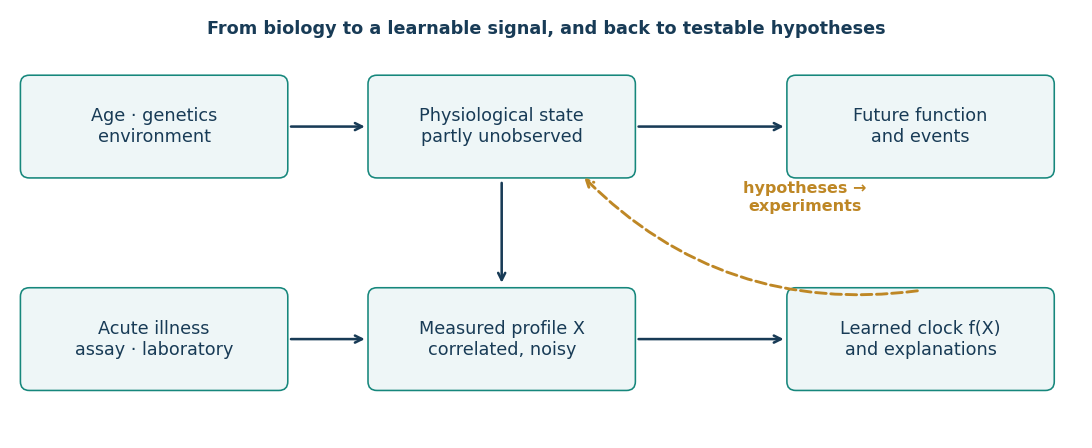

In [2]:
# A conceptual map, not an identified causal model or a result of either paper.
from matplotlib.patches import FancyBboxPatch
fig, ax = plt.subplots(figsize=(12, 4.8))
ax.set(xlim=(0, 12), ylim=(0, 4.8)); ax.axis("off")
nodes = {
    "upstream": (1.6, 3.5, "Age · genetics\nenvironment"),
    "state": (5.5, 3.5, "Physiological state\npartly unobserved"),
    "outcome": (10.2, 3.5, "Future function\nand events"),
    "context": (1.6, 1.1, "Acute illness\nassay · laboratory"),
    "x": (5.5, 1.1, "Measured profile X\ncorrelated, noisy"),
    "clock": (10.2, 1.1, "Learned clock f(X)\nand explanations")}
for key, (x, y, label) in nodes.items():
    ax.add_patch(FancyBboxPatch((x-1.4, y-.48), 2.8, .96,
                              boxstyle="round,pad=.10", fc="#eef6f7", ec=TEAL))
    ax.text(x, y, label, ha="center", va="center", color=NAVY)
for a, b in [("upstream","state"), ("state","outcome"),
             ("state","x"), ("context","x"), ("x","clock")]:
    x1,y1,_=nodes[a]; x2,y2,_=nodes[b]
    if y1==y2: x1+=1.5; x2-=1.5
    else: y1-=.6; y2+=.6
    ax.annotate("", (x2,y2), (x1,y1), arrowprops={"arrowstyle":"->", "color":NAVY, "lw":1.6})
ax.annotate("", (6.4, 2.95), (10.2, 1.65),
            arrowprops={"arrowstyle":"->", "color":GOLD, "lw":1.8, "ls":"--", "connectionstyle":"arc3,rad=-.25"})
ax.text(8.9, 2.55, "hypotheses →\nexperiments", color=GOLD, ha="center", fontsize=10, weight="bold")
ax.text(6, 4.55, "From biology to a learnable signal, and back to testable hypotheses",
        ha="center", weight="bold", color=NAVY)
finish(fig, "01_conceptual_map", alt="Conceptual map: age, genetics and environment drive a partly unobserved physiological state, which produces the measured profile and future outcomes; the learned clock feeds hypotheses back to experiments")

<a id="dictionary"></a>
<div style="border-left:6px solid #5b4a8b;background:#f3f0f9;color:#1d3540;padding:12px 20px;border-radius:8px;margin:16px 0">

<span style="color:#5b4a8b;font-weight:700;letter-spacing:1.5px;font-size:12px">TRANSLATION</span> **A two-way dictionary**

**For mathematicians.** *NMR spectrum*: a vector of correlated intensities (P1's age model uses 1,039 bins, p. 12). *NOESY / CPMG / J-resolved*: three acquisition protocols; CPMG attenuates signals from large molecules such as proteins and lipoproteins, and J-resolved spectra separate overlapping peaks. *FID*: the raw time-domain signal before the Fourier transform. *GlycA/GlycB*: NMR inflammation signals from glycoproteins. *ESR*: how fast red blood cells settle, an inflammation marker. *eGFR*: estimated kidney filtration rate. *IVDr*: standardized, automated commercial NMR quantification reports. *Cohort*: a recruited study population.

**For biologists.** *Condition number κ*: how much small measurement errors can be amplified when model weights are estimated (κ > 30 is a common warning sign). *ERM*: choose the model that minimizes the average error. $\mathbb E[A\mid X]$: the average age of people who share this profile. *Shapley value*: fair credit, averaged over all orders in which the measurements could be revealed. *K–S test*: compares two whole distributions. *Conformal interval*: a prediction band with a guaranteed average coverage.

The full glossary is in [section 15](#references).

</div>

<a id="challenge"></a>
## 2 · The challenge: from serum to a learnable, explainable signal

*Why this is exciting:* NMR is reproducible, needs little sample preparation and scales to biobanks, so the measurement is already population-ready [P1, p. 2].

**Five challenges, five research opportunities.**

| Challenge | Opportunity it opens | Where in this notebook |
|---|---|---|
| 1. No ground-truth biological age | Outcome-anchored validation; disease cohorts as natural experiments | 3, 10.1 |
| 2. Redundant, correlated spectra | Biologically curated, well-conditioned representations | 7, 10.1 |
| 3. Regression to the mean | Reference-adjusted distortion, and a theorem explaining the bias | 3, 6 |
| 4. Laboratory and population shift | Transportable clocks with calibrated uncertainty | 6, 10.1 |
| 5. Many outputs, one explanation? | The rigidity theorem for multi-output SHAP | 9, 10.2 |

**The measurement chain in P1:** serum → NMR acquisitions → quantified metabolites and NMR-inferred clinical biomarkers → expert feature curation → age model → SHAP profiles → comparison with disease cohorts. [P1, Fig. 1, pp. 4–5; Methods, pp. 12–13]

- **NOESY** captures signals from all molecular components detectable by NMR; neighbouring bins reflect the same resonances, so the spectrum is informative but highly redundant.
- **CPMG** attenuates macromolecular signals; **J-resolved** spectra resolve overlap. Spiking experiments calibrate metabolite quantification.
- **Clinical proxies:** 25 routine clinical biomarkers are inferred from the spectra alongside 49 quantified metabolites. P1 treats them as semiquantitative proxies, not as replacements for laboratory assays.
- **Curation:** the initial 74 variables become 75 after removal (haemoglobin, fructosamine, total cholesterol), decomposition (non-albumin protein) and ratios (GlycB/GlycA, urea/creatinine, BCAA/AAA, lactate/pyruvate, glutamine/glutamate). More variables can mean less redundancy.

**P1's motivation.** Earlier NMR clocks show **regression to the mean**, overestimating the age of young people and underestimating the age of old people, and some were built on narrow age ranges (UK Biobank, 40–71 years). NMR-inferred clinical parameters had not been used to build clocks. P1 assembles 7–106 years, trains on an age- and sex-balanced subset (five age strata, p. 13) and reports that its curated clock mitigates regression to the mean. [P1, pp. 2, 5, 13]

**Two surprises worth a mathematician's attention.** Raw FID signals (512 complex points, p. 12) remain highly predictive of age with no Fourier transform (r = 0.89, RMSE 8.6 y vs 6.5 y for NOESY; p. 4). And 25 routine clinical biomarkers can be inferred from the same spectra, which P1 presents as new for clock construction (pp. 2, 5).

How P1 met these challenges is reported in [Part V](#results-p1).

<div style="background:#123047;color:white;padding:12px 20px;border-radius:8px;margin:28px 0 8px"><span style="color:#83d9c4;letter-spacing:2px;font-size:13px;font-weight:700">PART II · MATHEMATICAL FORMULATION</span><span style="color:#e4eef3"> — clocks as learning problems, explanations as cooperative games</span></div>

<a id="formulation"></a>
## 3 · Clocks as learning problems

*Why this is exciting:* once written as a learning problem, “biological age” becomes a set of precise, answerable mathematical questions.

Let $X_i\in\mathbb R^p$ be measured features, $A_i$ chronological age, $C_i$ observed context (cohort, assay, recorded sex, medication) and $Y_i$ an independent outcome. The latent state $B_i$ is not observed merely because we observe $A_i$.

**The clock.** A clock solves a regularized empirical risk minimization (ERM) problem,

$$\widehat\theta\in\operatorname*{argmin}_{\theta}
\frac1n\sum_{i=1}^{n}\big(f_\theta(X_i)-A_i\big)^2+\lambda\Omega(\theta).$$

Without penalty and over all square-integrable $f$, the population minimizer is

$$f^*(x)=\mathbb E[A\mid X=x]=\frac{\int a\,p(x\mid a)\,\pi(a)\,da}{\int p(x\mid a)\,\pi(a)\,da}.$$

Over a restricted class (for example linear models) the target is the $L^2$ projection of $f^*$ onto that class, and $\lambda>0$ adds bias. **The target is conditional chronological age, not an identified aging mechanism.** The formula shows that the age distribution $\pi$ of the training cohort is part of the target: P1's stratum balancing (equal counts across five age strata of unequal width, p. 13) reshapes $\pi$; it is a modelling choice, not a neutral preprocessing step.


<div style="border-left:6px solid #5b4a8b;background:#f3f0f9;color:#1d3540;padding:12px 20px;border-radius:8px;margin:16px 0">

<span style="color:#5b4a8b;font-weight:700;letter-spacing:1.5px;font-size:12px">TRANSLATION</span> **In one line**

The clock learns the average age of people whose profiles look like yours, in the reference population it was trained on.

</div>

### Three numbers that should never be conflated

$$\text{clock output: }\widehat A=f(X),\qquad
\text{raw age gap: }G=f(X)-A,$$
$$\text{reference-adjusted distortion: }D=f(X)-\widehat m(A),\qquad
\widehat m(a)\approx\mathbb E_{ref}[f(X)\mid A=a].$$

If $\mathbb E[f(X)\mid A=a]=\alpha+\beta a$, then $\mathbb E[G\mid A=a]=\alpha+(\beta-1)a=(\beta-1)(a-a_0)$ with crossing age $a_0=\alpha/(1-\beta)$. For $\beta<1$ people younger than $a_0$ look accelerated and people older than $a_0$ look decelerated, with no pathology at all. By construction $\mathbb E_{ref}[D\mid A]=0$, up to the accuracy of $\widehat m$. Residualization removes the reference trend; it does not by itself establish biological validity.


<div style="border-left:6px solid #183b56;background:#eef3f8;color:#1d3540;padding:12px 20px;border-radius:8px;margin:16px 0">

<span style="color:#183b56;font-weight:700;letter-spacing:1.5px;font-size:12px">THEOREM</span> **A theorem hidden in the age gap**

Let $f^*=\mathbb E[A\mid X]$ and $R^2=\operatorname{Var}(f^*)/\operatorname{Var}(A)$. Then $\operatorname{Cov}(f^*,A)=\operatorname{Var}(f^*)$, so the least-squares slope of $f^*$ on $A$ is

$$\beta=\frac{\operatorname{Cov}(f^*,A)}{\operatorname{Var}(A)}=R^2<1\quad\text{unless $X$ determines $A$ exactly,}$$

and $\operatorname{Cov}(G,A)=-(1-R^2)\operatorname{Var}(A)$ while $\operatorname{Cov}(G,f^*)=0$. *Proof:* $\operatorname{Cov}(f^*,A)=\mathbb E[f^*\,\mathbb E[A\mid X]]-\mathbb E[f^*]\mathbb E[A]=\operatorname{Var}(f^*)$.

**Consequence.** The raw gap of the *best possible* clock depends on age by necessity, not because of poor learning. Reference adjustment is a mathematical requirement, not a cosmetic fix. The lab in section 6 checks this numerically.

</div>

**How P1 uses these words.** P1 defines metabolic distortion as the deviation from the reference regression line (p. 7; Fig. 4 caption, p. 8). The negative-control passage describes it as metabolic minus chronological age (p. 6), and the Discussion describes disease distortion through SHAP differences from matched controls (p. 10). We keep the definitions explicit. [P1, pp. 6–8, 10]

### Explanations as cooperative games

For one person $x$, a coalition $S\subseteq\{1,\dots,p\}$ is the set of measurements revealed so far, and $v_x(S)=\mathbb E_\mu[f(X)\mid X_S=x_S]-\mathbb E_\mu[f(X)]$ is the change in expected prediction once they are known. The Shapley value of feature $j$ averages its increment over all orders of revelation (section 8). When $f$ has $m$ outputs, $v_x(S)\in\mathbb R^m$ is a **vector game** (section 9).

### Joint learning of several outputs

A shared representation $h_\theta(X)$ can feed several heads. P2 trains age $A$, MetSCORE $M$ and sex $S$ jointly with (p. 13)

$$\mathcal L=\operatorname{MSE}(\widehat A,A)+\operatorname{MSE}(\widehat M,M)+\ell_{BCE}(\widehat\ell,S),\qquad
\ell_{BCE}(\widehat\ell,S)=-\big[S\log\sigma(\widehat\ell)+(1-S)\log(1-\sigma(\widehat\ell))\big],$$

where $\widehat\ell$ is a logit and $\sigma$ the logistic function. Recorded sex is encoded as a binary target, which describes the dataset, not a model of sex or gender. **Scale matters.** At P2's reported errors, an unscaled age MSE (≈ 8.31² ≈ 69 years²) exceeds the MetSCORE MSE (≈ 0.112² ≈ 0.012) by a factor of about 5,500. P2 reports standardizing inputs; target scaling is not stated. Standardizing targets (as our lab does), or adaptive weights such as uncertainty weighting, GradNorm or Pareto/MGDA methods, changes what “equal weights” means. This connects to the weak-Pareto view of joint training in P2, Appendix B.3 (p. 25) and to P2's open problem 3.

<div style="background:#123047;color:white;padding:12px 20px;border-radius:8px;margin:28px 0 8px"><span style="color:#83d9c4;letter-spacing:2px;font-size:13px;font-weight:700">PART III · MATHEMATICAL GOALS</span><span style="color:#e4eef3"> — what we want to prove, measure and guarantee</span></div>

<a id="goals"></a>
## 4 · What we want to prove and measure

| Goal | Mathematical object / criterion | Biological interpretation |
|---|---|---|
| Predict | Held-out RMSE, MAE, $R^2$, calibration | How well does a molecular profile encode chronological age? |
| Validate biologically | Incremental prediction of $Y$ beyond age and standard covariates | Does the clock measure clinically relevant variation? |
| Stabilize | Sensitivity of predictions and explanations to perturbations; conditioning | Would repeated sampling or a new laboratory change our story? |
| Generalize | Risk $\mathbb E_{P_{new}}[\ell(f(X),A)]$ under shift | Does the clock travel to another population? |
| Explain | An allocation rule with axioms and a stated reference distribution | Which measurements support this model output? |
| Learn jointly | Several losses; the Pareto trade-off | Can related outcomes share information without harmful interference? |
| Infer causally | A defined intervention and assumptions that identify its effect | Would changing a pathway improve an outcome? |

**The multi-output question (P2).** Given $f:\mathbb R^n\to\mathbb R^m$ (age, a risk score, a class logit), is there a fair allocation that couples the outputs, for instance crediting a feature for age because it matters for risk? Section 9 answers with a theorem: under the Shapley axioms, no.

**Evaluation design.** Split by the unit of independence first (person, family or cohort); learn imputation, scaling and feature selection within training folds; tune on training/validation data; fit any reference correction separately; open the test set only once. For a spectrum → inferred biomarker → age stack, check overlap at **both stages**. Age-dependent formulas, such as some eGFR definitions, also need an explicit check for encoded age information. [P1, Methods; [scikit-learn guidance](https://scikit-learn.org/stable/common_pitfalls.html)]

<div style="background:#123047;color:white;padding:12px 20px;border-radius:8px;margin:28px 0 8px"><span style="color:#83d9c4;letter-spacing:2px;font-size:13px;font-weight:700">PART IV · MATHEMATICS IN ACTION</span><span style="color:#e4eef3"> — a synthetic laboratory you can run, modify and break</span></div>

<a id="clocklab"></a>
## 5 · SYNTHETIC LAB: build a small clock correctly

*Why this is exciting:* a few lines of scikit-learn reproduce the core pipeline, so anyone can experiment.

We generate **1,800 artificial adults**, 12 correlated marker-like features and three unobserved physiological factors. Every feature is in arbitrary simulation units. Correlated GlycA-like/GlycB-like measurements mimic the redundancy P1 met in real data (section 7). The simulation contains age-related signal and within-age variation; it does **not** contain a validated biological age or an outcome endpoint.

**Predict before running:** will a more flexible learner necessarily beat a regularized linear model when the data-generating mechanism is largely linear?

Training 1080 | reference calibration 360 | untouched test 360


,Albumin-like,ESR-like,GlycA-like,GlycB-like,Urea-like,Creatinine-like,Glucose-like,Lactate-like,Amino-acid-like,Lipid-like,Muscle-like,Protein-like
0,-1.07,0.91,0.83,0.90,-0.55,0.14,-0.47,-1.28,1.97,-1.96,0.90,-0.63
1,-0.46,0.46,0.10,0.13,0.88,-0.42,-0.09,-0.25,-0.87,-0.02,-1.25,0.02
2,-0.25,0.22,0.31,0.31,-0.44,1.18,-0.33,-0.83,0.23,-0.52,0.45,-0.28
3,0.65,-0.84,-0.72,-0.81,0.49,0.02,-0.40,0.22,0.21,-0.63,0.46,0.47
4,-0.73,0.63,0.32,0.35,-0.77,0.14,-0.32,0.43,-0.04,-0.06,-0.07,-0.35


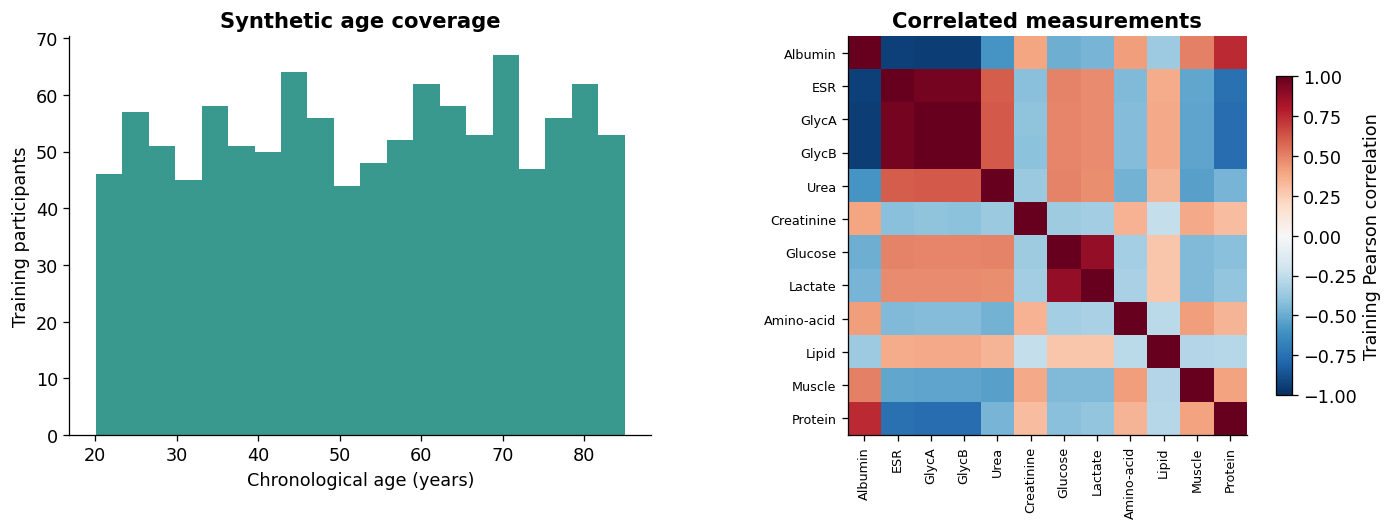

In [3]:
def simulate_cohort(n=1800, seed=SEED):
    '''Synthetic cohort: three latent factors drive 12 correlated marker-like features.'''
    rng = np.random.default_rng(seed)
    age = rng.uniform(20, 85, n)
    az = (age - 52.5) / 18.8
    inflammation = .85*az + rng.normal(0, .65, n)
    renal = .90*az + rng.normal(0, .65, n)
    energy = .65*az + rng.normal(0, .75, n)
    noise = lambda s: rng.normal(0, s, n)
    glyca = inflammation + noise(.20)
    X = pd.DataFrame({
        "Albumin-like": -inflammation + noise(.30),
        "ESR-like": inflammation + noise(.25),
        "GlycA-like": glyca,
        "GlycB-like": 1.02*glyca + noise(.04),
        "Urea-like": renal + noise(.30),
        "Creatinine-like": -.40*az + noise(.65),
        "Glucose-like": energy + noise(.30),
        "Lactate-like": energy + noise(.45),
        "Amino-acid-like": -.55*az + noise(.70),
        "Lipid-like": .40*az + noise(.80),
        "Muscle-like": -.65*az + noise(.65),
        "Protein-like": -.60*inflammation + noise(.55)})
    return X, pd.Series(age, name="Chronological age")

X, age = simulate_cohort()
ids = np.arange(len(X))
train_ids, rest_ids = train_test_split(ids, test_size=.40, random_state=SEED)
cal_ids, test_ids = train_test_split(rest_ids, test_size=.50, random_state=SEED+1)
assert not (set(train_ids) & set(cal_ids) or set(train_ids) & set(test_ids) or set(cal_ids) & set(test_ids))
Xtr, Xcal, Xte = [X.iloc[idx] for idx in (train_ids, cal_ids, test_ids)]
atr, acal, ate = [age.iloc[idx] for idx in (train_ids, cal_ids, test_ids)]
print(f"Training {len(Xtr)} | reference calibration {len(Xcal)} | untouched test {len(Xte)}")
display(X.head().round(2))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), layout="constrained")
axes[0].hist(atr, bins=20, color=TEAL, alpha=.85)
axes[0].set(xlabel="Chronological age (years)", ylabel="Training participants",
            title="Synthetic age coverage")
im = axes[1].imshow(Xtr.corr(), cmap="RdBu_r", vmin=-1, vmax=1)
axes[1].set_xticks(range(12), [s.replace("-like", "") for s in X], rotation=90, fontsize=8)
axes[1].set_yticks(range(12), [s.replace("-like", "") for s in X], fontsize=8)
axes[1].set_title("Correlated measurements")
fig.colorbar(im, ax=axes[1], label="Training Pearson correlation", shrink=.8)
finish(fig, "03_synthetic_cohort")

,RMSE (years),MAE (years),R²,Pearson r
Training-mean baseline,19.274,16.822,-0.000,— (constant prediction)
Ridge (training CV),7.046,5.593,0.866,0.931
ExtraTrees (fixed settings),7.451,5.926,0.851,0.924


Selected Ridge alpha: 10


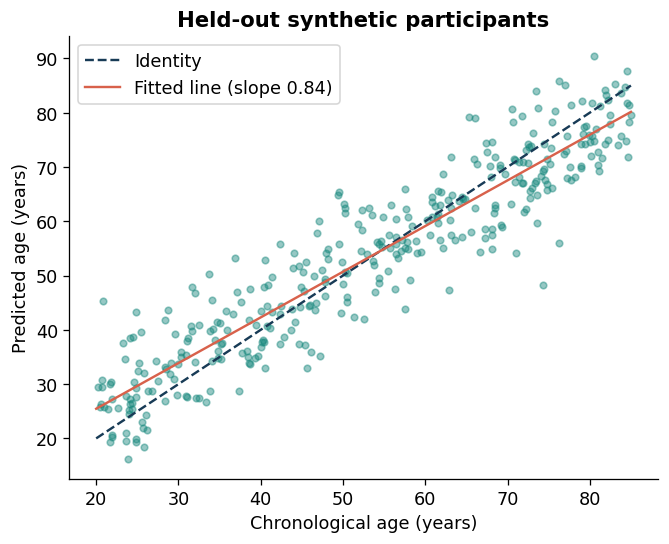

In [4]:
# All data-dependent preprocessing and Ridge tuning stay inside training folds.
ridge_search = GridSearchCV(
    make_pipeline(SimpleImputer(strategy="median"), StandardScaler(), Ridge()),
    {"ridge__alpha": [0.1, 1, 10, 100]},
    cv=KFold(5, shuffle=True, random_state=SEED),
    scoring="neg_mean_squared_error", n_jobs=1)
ridge_search.fit(Xtr, atr)
clock = ridge_search.best_estimator_
models = {
    "Training-mean baseline": DummyRegressor().fit(Xtr, atr),
    "Ridge (training CV)": clock,
    "ExtraTrees (fixed settings)": make_pipeline(
        SimpleImputer(strategy="median"),
        ExtraTreesRegressor(n_estimators=120, min_samples_leaf=5,
                            random_state=SEED, n_jobs=1)).fit(Xtr, atr)}

def metrics(y, pred):
    return {"RMSE (years)": np.sqrt(mean_squared_error(y, pred)),
            "MAE (years)": mean_absolute_error(y, pred),
            "R²": r2_score(y, pred),
            "Pearson r": np.corrcoef(y, pred)[0,1] if np.std(pred)>1e-10 else np.nan}

test_metrics = pd.DataFrame({name: metrics(ate, model.predict(Xte))
                             for name, model in models.items()}).T
display(test_metrics.round(3).fillna("— (constant prediction)"))
print("Selected Ridge alpha:", ridge_search.best_params_["ridge__alpha"])
# Ridge is the predeclared explanatory model, not selected by inspecting test scores.
pred = clock.predict(Xte)
pred_cal = clock.predict(Xcal)
fig, ax = plt.subplots(figsize=(6.6, 5))
ax.scatter(ate, pred, alpha=.45, s=17, color=TEAL)
ax.plot([20,85], [20,85], "--", color=NAVY, label="Identity")
slope_test, intercept_test = np.polyfit(ate, pred, 1)
ax.plot([20,85], intercept_test+slope_test*np.array([20,85]), color=CORAL,
        label=f"Fitted line (slope {slope_test:.2f})")
ax.set(xlabel="Chronological age (years)", ylabel="Predicted age (years)",
       title="Held-out synthetic participants")
ax.legend(); finish(fig, "04_clock_predictions")

**Read the output.** Compare with the training-mean baseline before celebrating a correlation. Pearson $r$ measures association, not agreement: adding 15 years to every prediction leaves $r$ unchanged. RMSE and calibration reveal the error. Notice that the fitted line is flatter than the identity: section 3 predicted exactly this. These modest models are for transparent teaching; they do not reproduce P1's AutoML-selected stack.

**Researcher checkpoint.** A random person-level split is valid for this independent simulation. With relatives, repeated samples or laboratory structure it may be optimistic; use family or participant groups and a held-out cohort, and fit all upstream predictors inside the same isolation scheme.

<a id="calibration"></a>
## 6 · Reading age gaps correctly: bias, shift and calibrated uncertainty

*Why this is exciting:* reference-adjusted distortion turns a biased residual into a disease-sensitive signal; it is what P1 maps across 11 diseases [P1, p. 7].

We fit the reference line on the calibration set, compute the two deviations on test participants, and build a 90% **split-conformal prediction interval for chronological age**. With calibration scores $s_i=|A_i-f(X_i)|$, take $q$ = the $k$-th smallest score with $k=\lceil(n_{cal}+1)(1-\alpha)\rceil$, and report $[f(x)-q,f(x)+q]$.

**The guarantee, stated precisely.** If calibration and test pairs are exchangeable and $f$ was fitted on separate data, then
$$1-\alpha\le P\big(|A_{new}-f(X_{new})|\le q\big)\le 1-\alpha+\tfrac{1}{n_{cal}+1}$$
(the upper bound assumes no ties), with probability taken over both calibration and test draws; if $k>n_{cal}$ then $q=\infty$. For one fixed calibration set, coverage is itself random (Beta-distributed). Exact coverage conditional on $X=x$ for every $x$ is impossible distribution-free without trivial intervals (Vovk 2012; Barber et al. 2021). This is an interval for chronological age, not a confidence interval for a person's true biological age. [[Angelopoulos & Bates](https://arxiv.org/abs/2107.07511)]

The predictor is frozen before calibration. The reference line and conformal scores use the same calibration observations for **separate purposes**.

Reference line: expected prediction = 7.49 + 0.866 × chronological age
Section-3 theorem check: slope 0.866 vs R² 0.853 (calibration) and 0.866 (test); crossing age a0 = 56.0 years
90% chronological-age interval: prediction ± 11.6 years; test coverage 90.8% (coverage given this calibration set ~ Beta(325,36), SD 0.016)
95% bootstrap interval for test RMSE: [6.51 7.56]


,n,mean_gap,mean_distortion,interval_coverage,binomial SE of coverage
Age band,,,,,
20–40,108,3.776,0.221,0.889,0.029
40–60,103,0.958,0.121,0.903,0.030
60–85,149,-2.903,-0.658,0.926,0.025


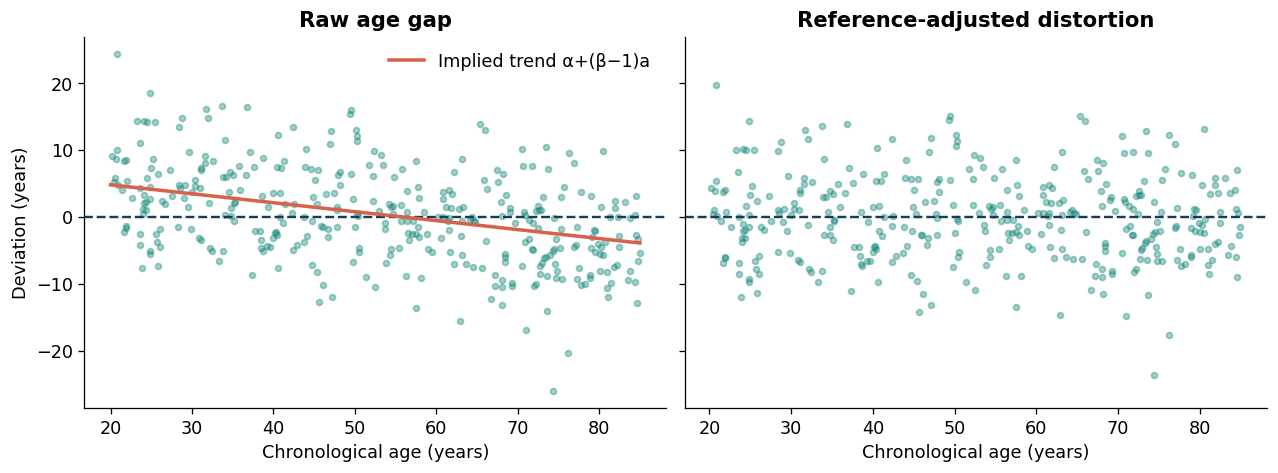

In [5]:
reference = LinearRegression().fit(acal.to_numpy()[:,None], pred_cal)
expected_test = reference.predict(ate.to_numpy()[:,None])
raw_gap = pred - ate.to_numpy()
distortion = pred - expected_test
alpha_ref, beta_ref = reference.intercept_, reference.coef_[0]
print(f"Reference line: expected prediction = {alpha_ref:.2f} + {beta_ref:.3f} × chronological age")
print(f"Section-3 theorem check: slope {beta_ref:.3f} vs R² {r2_score(acal, pred_cal):.3f} (calibration) "
      f"and {r2_score(ate, pred):.3f} (test); crossing age a0 = {alpha_ref/(1-beta_ref):.1f} years")

alpha = .10
scores = np.abs(acal.to_numpy() - pred_cal)
k_conf = math.ceil((len(scores)+1)*(1-alpha))
q = np.sort(scores)[k_conf-1] if k_conf <= len(scores) else np.inf
coverage = np.mean(np.abs(ate.to_numpy()-pred) <= q)
a_beta, b_beta = k_conf, len(scores)+1-k_conf
sd_beta = math.sqrt(a_beta*b_beta/((a_beta+b_beta)**2*(a_beta+b_beta+1)))
print(f"90% chronological-age interval: prediction ± {q:.1f} years; test coverage {coverage:.1%} "
      f"(coverage given this calibration set ~ Beta({a_beta},{b_beta}), SD {sd_beta:.3f})")

# Participant bootstrap: uncertainty in RMSE for this frozen predictor and test distribution.
boot_rng = np.random.default_rng(SEED+2)
boot = boot_rng.integers(0, len(ate), size=(600, len(ate)))
rmse_boot = np.sqrt(np.mean((ate.to_numpy()-pred)[boot]**2, axis=1))
print("95% bootstrap interval for test RMSE:", np.quantile(rmse_boot,[.025,.975]).round(2))

age_bands = pd.cut(ate.to_numpy(), [20,40,60,85], labels=["20–40","40–60","60–85"], include_lowest=True)
summary = pd.DataFrame({"Age band": age_bands, "Gap": raw_gap, "Distortion": distortion,
                        "Covered": np.abs(ate.to_numpy()-pred)<=q})
band_table = summary.groupby("Age band", observed=True).agg(
    n=("Gap","size"), mean_gap=("Gap","mean"),
    mean_distortion=("Distortion","mean"), interval_coverage=("Covered","mean"))
band_table["binomial SE of coverage"] = np.sqrt(.9*.1/band_table["n"])
display(band_table.round(3))

a_grid = np.linspace(20, 85, 50)
fig, axes = plt.subplots(1,2, figsize=(11,4), sharey=True, layout="constrained")
for ax, residual, title in zip(axes,[raw_gap,distortion],["Raw age gap", "Reference-adjusted distortion"]):
    ax.scatter(ate, residual, s=14, alpha=.4)
    ax.axhline(0,color=NAVY,ls="--")
    ax.set(xlabel="Chronological age (years)",title=title)
axes[0].plot(a_grid, alpha_ref+(beta_ref-1)*a_grid, color=CORAL, lw=2.2, label="Implied trend α+(β−1)a")
axes[0].legend(frameon=False)
axes[0].set_ylabel("Deviation (years)")
finish(fig, "05_gap_and_distortion")

**Read the output.** The fitted slope is close to $R^2$ (within about 0.01), as the section-3 theorem predicts for a near-optimal clock. The raw gap trends with age; the distortion does not. With about 100–150 people per age band, coverage differences of ±3% are within sampling error (see the binomial SE column): this table does not demonstrate subgroup failure.

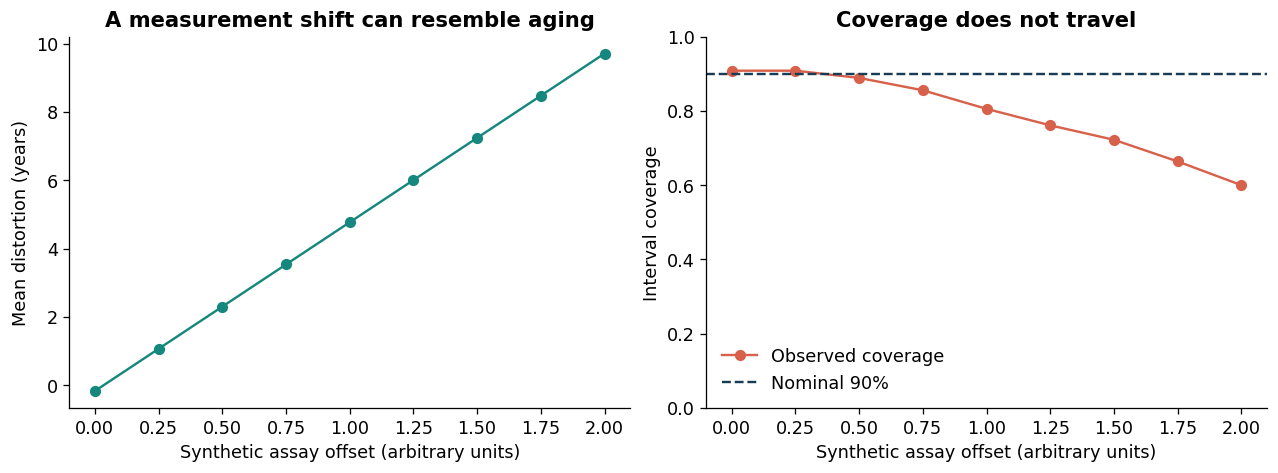

In [6]:
# Synthetic laboratory offset: a systematic shift in four inflammation-related features
# (GlycB-like is shifted by 1.02 x the offset to keep its relation to GlycA-like).
# Identical people and ages make the perturbation's effect unambiguous in this toy example.
def shift_features(frame, amount):
    shifted = frame.copy()
    shifted["Albumin-like"] -= amount
    shifted["ESR-like"] += amount
    shifted["GlycA-like"] += amount
    shifted["GlycB-like"] += 1.02*amount
    return shifted

shift_records = []
for amount in np.linspace(0,2,9):
    shifted_pred = clock.predict(shift_features(Xte, amount))
    shift_records.append({"Offset (arbitrary units)": amount,
                          "RMSE (years)": np.sqrt(mean_squared_error(ate,shifted_pred)),
                          "Coverage": np.mean(np.abs(ate.to_numpy()-shifted_pred)<=q),
                          "Mean distortion (years)": np.mean(shifted_pred-expected_test)})
shift_table = pd.DataFrame(shift_records)
fig, axes = plt.subplots(1,2,figsize=(11,4),layout="constrained")
axes[0].plot(shift_table.iloc[:,0],shift_table["Mean distortion (years)"],"o-")
axes[0].set(xlabel="Synthetic assay offset (arbitrary units)",ylabel="Mean distortion (years)",
            title="A measurement shift can resemble aging")
axes[1].plot(shift_table.iloc[:,0],shift_table.Coverage,"o-",color=CORAL, label="Observed coverage")
axes[1].axhline(.9,ls="--",color=NAVY, label="Nominal 90%")
axes[1].set(xlabel="Synthetic assay offset (arbitrary units)",ylabel="Interval coverage",
            ylim=(0,1),title="Coverage does not travel")
axes[1].legend(frameon=False)
finish(fig,"06_domain_shift")

### Interactive window · Shrinkage alone can produce an age gap

This is exactly the defect P1 set out to reduce: compare the slope in P1 Fig. 2a (reproduced in [section 10.1](#results-p1)) with the slider values. By the section-3 theorem, an optimal clock with P1's correlation R = 0.884 would sit near slope R² ≈ 0.78 on this slider, not at 1. At slope one the age trend in the raw gap disappears; at lower slopes the extremes bend toward the mean. The construction is algebraic, not a fitted disease model. The figure below is a static preview; in a running kernel the slider redraws it.

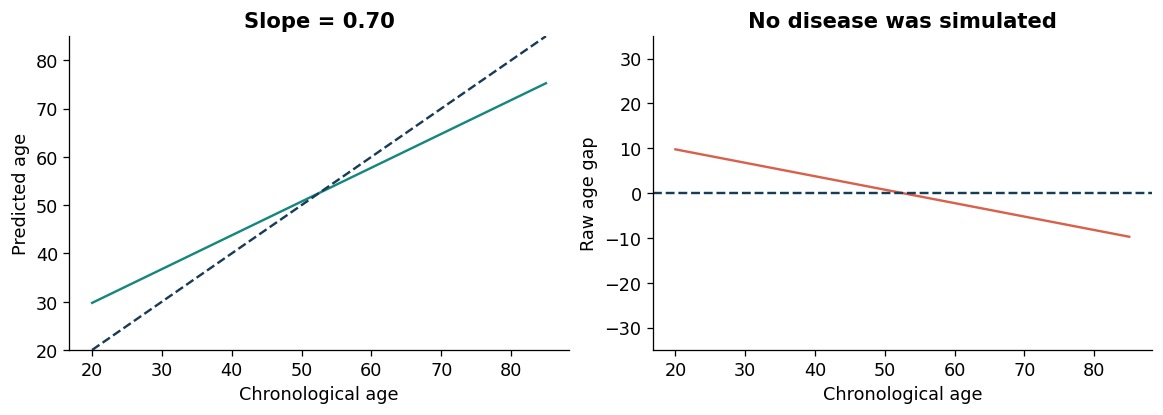

In [7]:
def shrinkage_figure(slope=.70):
    a = np.linspace(20,85,100)
    prediction = 52.5+slope*(a-52.5)
    fig, axes = plt.subplots(1,2,figsize=(10,3.5),layout="constrained")
    axes[0].plot(a,prediction,color=TEAL); axes[0].plot(a,a,"--",color=NAVY)
    axes[0].set(xlabel="Chronological age",ylabel="Predicted age",ylim=(20,85),title=f"Slope = {slope:.2f}")
    axes[1].plot(a,prediction-a,color=CORAL); axes[1].axhline(0,color=NAVY,ls="--")
    axes[1].set(xlabel="Chronological age",ylabel="Raw age gap",ylim=(-35,35),title="No disease was simulated")
    return fig

controls = ({"slope": widgets.FloatSlider(value=.70, min=0, max=1, step=.05, description="Slope",
                                          continuous_update=False)} if HAS_WIDGETS else None)
live_window(shrinkage_figure, controls, slope=.70)

### Short video 1 · An apparent age gap without accelerated aging

**Watch for:** what changes when the prediction slope moves from one toward zero? **Transcript:** Predictions first follow chronological age. As the slope decreases, younger participants are predicted older and older participants younger. The raw age gap acquires an age trend although no disease or intervention has been introduced. A reference correction, estimated on independent reference data, removes it.

In [8]:
video_path = ROOT / "assets" / "videos" / "01_age_gap.mp4"
if video_path.exists():
    display(Video(str(video_path), embed=True, width=850,
                  html_attributes='controls preload="metadata" aria-label="Animation of regression to the mean and age gaps"'))
else:
    print("Video asset not present. The transcript and interactive shrinkage window explain the same concept.")

<div style="border-left:6px solid #16877c;background:#eef7f5;color:#1d3540;padding:12px 20px;border-radius:8px;margin:16px 0">

<span style="color:#16877c;font-weight:700;letter-spacing:1.5px;font-size:12px">MAIN CONCLUSION</span> **First lab**

Even the best clock has an age-dependent raw gap (slope $=R^2<1$); the reference-adjusted distortion removes it, and conformal intervals give honest average coverage. An assay shift can mimic aging, so external cohorts and age-conditioned errors are the next checks before a score is read biologically.

</div>

<a id="collinearity"></a>
## 7 · Collinearity: why curated biomarkers make explanations stable

*Why this is exciting:* this is where numerical analysis meets biochemistry: expert curation made P1's SHAP profiles stable [P1, p. 5].

For a standardized design matrix $Z=\sum_k\sigma_k u_kv_k^T$ the spectral condition number is $\kappa_2(Z)=\sigma_{max}/\sigma_{min}$. Ordinary least squares has

$$\operatorname{Var}(\widehat\beta_{OLS})=\sigma^2\sum_k\frac{v_kv_k^T}{\sigma_k^2},$$

so for two near-duplicate markers the *difference* direction $v_{min}\propto(1,-1)$ has standard deviation $\sigma/\sigma_{min}$, while the *sum* direction is well determined. Ridge,

$$\widehat\beta_{ridge}=(Z^TZ+\lambda I)^{-1}Z^Ty,$$

replaces $1/\sigma_k$ by $\sigma_k/(\sigma_k^2+\lambda)$, and the condition number of the solved system falls from $\kappa(Z)^2$ to $(\sigma_{max}^2+\lambda)/(\sigma_{min}^2+\lambda)$.


<div style="border-left:6px solid #5b4a8b;background:#f3f0f9;color:#1d3540;padding:12px 20px;border-radius:8px;margin:16px 0">

<span style="color:#5b4a8b;font-weight:700;letter-spacing:1.5px;font-size:12px">TRANSLATION</span> **Biological translation**

If two measurements carry almost the same information, many allocations of model weight predict equally well. The prediction is robust, but the story about *which* marker matters changes from sample to sample. The threshold κ = 30 used in P1 is a diagnostic convention (Belsley et al.), not a universal boundary.

</div>

<div style="border-left:6px solid #16877c;background:#eef7f5;color:#1d3540;padding:12px 20px;border-radius:8px;margin:16px 0">

<span style="color:#16877c;font-weight:700;letter-spacing:1.5px;font-size:12px">MAIN CONCLUSION</span> **REPORTED [P1, pp. 4–5] · The real case behind this lab**

P1 reports κ ≈ 1.5 × 10⁴ for binned NOESY spectra, κ ≈ 38 for the initial 74 quantified/inferred biomarkers and κ ≈ 16 after expert curation (Fig. 1). Before curation, **GlycA and GlycB both received high SHAP importance with opposite signs**, which P1 calls physiologically implausible. Replacing GlycB by the GlycB/GlycA ratio (and removing other redundancies) lowered κ to about 16 and gave “stable and coherent SHAP value distributions”. Our GlycA-like/GlycB-like pair reproduces this mechanism synthetically.

</div>

**SYNTHETIC LAB.** Bootstrap an almost duplicated pair. Compare each coefficient, their sum, and predictions at a typical point $(1,1)$ *on* the data manifold and at an atypical point $(1,-1)$ *off* it, with the SVD theory above.

Singular values [26.457  0.199]; condition number κ(Z) = 132.7; κ(ZᵀZ) = 17,609; κ(ZᵀZ + I) = 674


,SD coefficient 1,SD coefficient 2,SD coefficient sum,"SD prediction at (1,1)","SD prediction at (1,−1) [off-manifold]"
OLS,2.616,2.619,0.043,0.061,5.235
Ridge,0.100,0.103,0.043,0.061,0.204
OLS theory (σ√diag (ZᵀZ)⁻¹),2.837,2.837,0.043,0.060,5.675


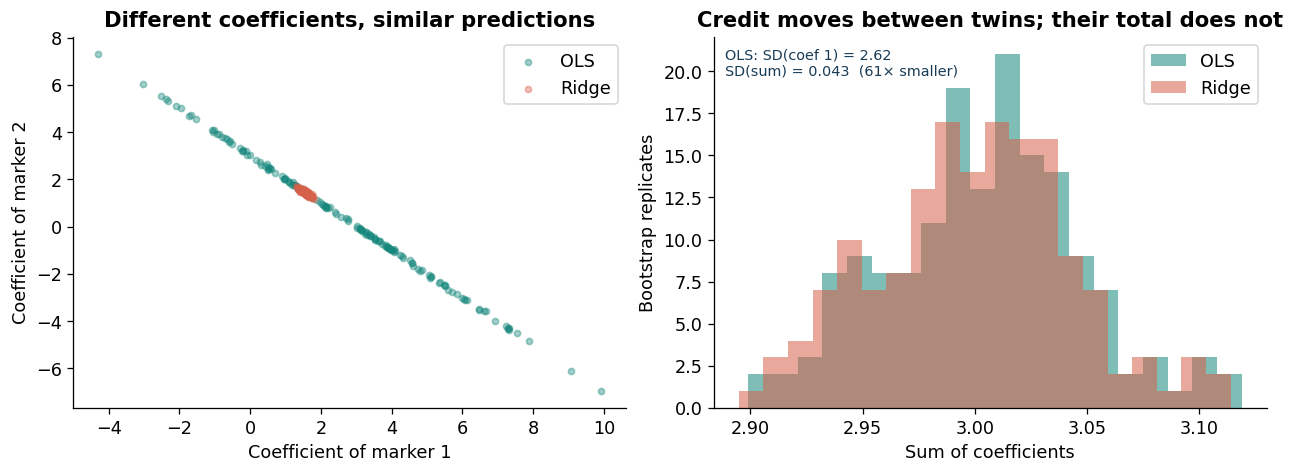

In [9]:
crng = np.random.default_rng(SEED+3)
z1 = crng.normal(size=350)
Z = np.column_stack([z1, z1+crng.normal(0,.015,350)])
Z = StandardScaler().fit_transform(Z)
noise_sd = .8
y = 3*z1 + crng.normal(0,noise_sd,350)
points = {"(1,1)": np.array([1.,1.]), "(1,−1)": np.array([1.,-1.])}
coef_samples = {"OLS": [], "Ridge": []}
point_predictions = {name: {p: [] for p in points} for name in coef_samples}
for _ in range(160):
    idx = crng.integers(0,len(y),len(y))
    for name, estimator in [("OLS",LinearRegression()),("Ridge",Ridge(alpha=1.0))]:
        fitted = estimator.fit(Z[idx],y[idx])
        coef_samples[name].append(fitted.coef_)
        for p, point in points.items():
            point_predictions[name][p].append(fitted.predict(point[None,:])[0])
coef_samples = {k:np.asarray(v) for k,v in coef_samples.items()}
singular = np.linalg.svd(Z, compute_uv=False)
print(f"Singular values {singular.round(3)}; condition number κ(Z) = {singular[0]/singular[1]:.1f}; "
      f"κ(ZᵀZ) = {(singular[0]/singular[1])**2:,.0f}; κ(ZᵀZ + I) = {(singular[0]**2+1)/(singular[1]**2+1):.0f}")
rows = {name:{"SD coefficient 1":c[:,0].std(), "SD coefficient 2":c[:,1].std(),
              "SD coefficient sum":c.sum(axis=1).std(),
              "SD prediction at (1,1)":np.std(point_predictions[name]["(1,1)"]),
              "SD prediction at (1,−1) [off-manifold]":np.std(point_predictions[name]["(1,−1)"])}
        for name,c in coef_samples.items()}
G_inv = np.linalg.inv(Z.T @ Z)
ones, diff = np.ones(2), np.array([1.,-1.])
rows["OLS theory (σ√diag (ZᵀZ)⁻¹)"] = {
    "SD coefficient 1": noise_sd*np.sqrt(G_inv[0,0]), "SD coefficient 2": noise_sd*np.sqrt(G_inv[1,1]),
    "SD coefficient sum": noise_sd*np.sqrt(ones@G_inv@ones),
    "SD prediction at (1,1)": noise_sd*np.sqrt(1/len(y)+ones@G_inv@ones),
    "SD prediction at (1,−1) [off-manifold]": noise_sd*np.sqrt(1/len(y)+diff@G_inv@diff)}
stability_table = pd.DataFrame(rows).T
display(stability_table.round(3))
fig, axes = plt.subplots(1,2,figsize=(11,4),layout="constrained")
for name,c in coef_samples.items():
    axes[0].scatter(c[:,0],c[:,1],alpha=.4,s=15,label=name)
    axes[1].hist(c.sum(axis=1),bins=20,alpha=.55,label=name)
sd1, sds = coef_samples["OLS"][:,0].std(), coef_samples["OLS"].sum(1).std()
axes[1].text(.02,.97, f"OLS: SD(coef 1) = {sd1:.2f}\nSD(sum) = {sds:.3f}  ({sd1/sds:.0f}× smaller)",
             transform=axes[1].transAxes, va="top", fontsize=9, color=NAVY)
axes[0].set(xlabel="Coefficient of marker 1",ylabel="Coefficient of marker 2",
            title="Different coefficients, similar predictions")
axes[1].set(xlabel="Sum of coefficients",ylabel="Bootstrap replicates",
            title="Credit moves between twins; their total does not")
axes[0].legend(); axes[1].legend(loc="upper right")
finish(fig,"07_collinearity")

**Read the output.** The SVD formulas predict the bootstrap almost exactly. On the data manifold the prediction is stable for both estimators; **off the manifold**, at the unusual profile $(1,-1)$, the OLS prediction is highly unstable. Keep this in mind for section 9: explanation methods that evaluate the model at unusual profiles (marginal masking) inherit exactly this instability.

### Short video 2 · Credit moves, prediction stays

*Context (collinearity, section 7):* when two measurements carry almost the same information, many weightings predict equally well, so the credit given to each is unstable even though the prediction is not. This is the problem P1 met with GlycA and GlycB before curation.

**Watch for:** the cloud of fitted weights versus the histogram of predictions. **Transcript:** Without regularization the two markers trade credit wildly between bootstrap samples, yet the prediction at a typical profile barely moves. As the ridge penalty λ grows, the cloud collapses to equal shares. The number on screen is the condition number of the solved system ZᵀZ + λI: it equals κ(Z)² ≈ 17,600 at λ = 0 (κ(Z) ≈ 133) and falls to about 24 at λ = 30. Ridge conditions the solved system; it does not change the feature matrix. P1 instead lowered κ of the feature matrix itself by changing the representation: about 15,000 for spectral bins, 38 for the initial biomarkers and 16 after expert curation.

In [10]:
video_path = ROOT / "assets" / "videos" / "02_collinearity.mp4"
if video_path.exists():
    display(Video(str(video_path), embed=True, width=850,
                  html_attributes='controls preload="metadata" aria-label="Animation of coefficient instability under collinearity and its cure by ridge regularization"'))
else:
    print("Video asset not present. The collinearity lab above shows the same effect.")

**What this experiment establishes:** correlated features can undermine individual allocations even when predictions stay stable near the data. It does not establish that every SHAP method is unstable, or that removing correlations yields a mechanistic explanation.

**Joint design choices:** measure technical replicates; prefer reliable features; evaluate sensible pathway groups; bootstrap the whole pipeline; report sensitivity to the background population. Ratios can encode domain knowledge, but small denominators amplify noise and algebraic overlap can create new dependencies. Check both numerics and physiology.

<a id="shap"></a>
## 8 · SHAP: from a coalition game to a model explanation

*Why this is exciting:* game theory gives explanations that satisfy stated axioms, rather than heuristics.

For one individual $x$, let $N=\{1,\dots,p\}$ index the features and $\mu$ be a stated reference distribution. P2 uses the **conditional** centered game (P2, eq. 2.7, p. 10)

$$v_x^{cond}(S)=\mathbb E_\mu[f(X)\mid X_S=x_S]-\mathbb E_\mu[f(X)].$$

The Shapley allocation averages the change in the model's expected output caused by revealing feature $j$, over all orders of revelation:

$$\phi_j(v)=\sum_{S\subseteq N\setminus\{j\}}
\frac{|S|!(p-|S|-1)!}{p!}\,[v(S\cup\{j\})-v(S)].$$

It is the unique rule satisfying **efficiency** ($\sum_j\phi_j=v(N)$), **symmetry** (equivalent players receive equal shares), **null player** (P2: *dummy player*; no increment means zero credit) and **linearity** (P2: *additivity*, i.e. linearity in the game). For the prediction game this gives the reconstruction identity (P2, Prop. 2.12)

$$f(x)=\mathbb E_\mu[f(X)]+\sum_j\phi_j(f;x).$$

P2 writes $n$ features indexed by $i$. [P2, Def. 2.3, Thms 2.4–2.5, p. 6; Prop. 2.12, p. 11] “Fair” here means these allocation axioms, not demographic fairness or causal validity. A full game has $2^p$ coalitions, which motivates specialized or approximate algorithms.


<div style="border-left:6px solid #5b4a8b;background:#f3f0f9;color:#1d3540;padding:12px 20px;border-radius:8px;margin:16px 0">

<span style="color:#5b4a8b;font-weight:700;letter-spacing:1.5px;font-size:12px">TRANSLATION</span> **Why Shapley and not attention or gradients? [P2, §1.3, pp. 3–4]**

Attention weights and many gradient or propagation methods describe **information routing**, i.e. how a network builds its internal representations. Shapley values describe **output attribution**: how the input variables account for the realized prediction, through conditional expectations of the predictor itself, with a uniqueness theorem behind them.

</div>

### A second legitimate game asks a different question

The **marginal (interventional) masking** game averages $f(x_S,X_{-S})$ over the marginal background of the missing variables. It can combine observed values into profiles that are unusual under their joint distribution (the off-manifold point of section 7). Conditional SHAP respects statistical dependence but can give credit to a correlated feature the predictor never uses. Marginal SHAP is “true to the model”, conditional SHAP “true to the data” (Chen, Janizek, Lundberg & Lee, 2020). Neither choice, by itself, identifies the effect of a biological intervention. [Marginal game: [SHAP LinearExplainer documentation](https://shap.readthedocs.io/en/latest/generated/shap.LinearExplainer.html); P2 itself works only with the conditional game (2.7), p. 10]

In [11]:
def exact_shapley(game):
    '''Exact Shapley values from all 2**p coalitions (bit-mask row order).

    Scalar game: array (2**p,); vector game: array (2**p, m).
    This is an exponential teaching implementation, not a high-dimensional explainer.
    '''
    values = np.asarray(game,dtype=float)
    scalar = values.ndim == 1
    if scalar:
        values = values[:,None]
    p = int(round(np.log2(len(values))))
    if 2**p != len(values) or not np.allclose(values[0],0):
        raise ValueError("Use a complete centered game with 2**p rows.")
    phi = np.zeros((p,values.shape[1]))
    for j in range(p):
        for mask in range(2**p):
            if mask & (1<<j):
                continue
            size = mask.bit_count()
            weight = math.factorial(size)*math.factorial(p-size-1)/math.factorial(p)
            phi[j] += weight*(values[mask | (1<<j)]-values[mask])
    return phi[:,0] if scalar else phi

def linear_gaussian_game(B, x, covariance, conditional=True):
    '''Centered game for f(x)=base+x@B with X~N(0,covariance).

    conditional=True: E[X | X_S=x_S] = A_S x_S with A_S = Sigma[:,S] Sigma[S,S]^{-1} (P2, eq. B.2).
    conditional=False: marginal masking, missing features set to their mean 0.
    '''
    B, x, covariance = np.asarray(B), np.asarray(x), np.asarray(covariance)
    if B.ndim == 1:
        B = B[:,None]
    p = len(x)
    values = np.zeros((2**p,B.shape[1]))
    for mask in range(1,2**p):
        S = [j for j in range(p) if mask & (1<<j)]
        if conditional:
            mean = covariance[:,S] @ np.linalg.solve(covariance[np.ix_(S,S)],x[S])
        else:
            mean = np.zeros(p); mean[S] = x[S]
        values[mask] = mean @ B
    return values

# The model f(x)=x1 does not use x2, but x2 is informative about x1.
rho = .85
sigma2 = np.array([[1,rho],[rho,1]])
rows = {}
for label, x2 in [("x = (2, 2)", np.array([2.,2.])), ("x = (2, −2)", np.array([2.,-2.]))]:
    cond = exact_shapley(linear_gaussian_game([1.,0.],x2,sigma2))[:,0]
    marg = exact_shapley(linear_gaussian_game([1.,0.],x2,sigma2,False))[:,0]
    assert np.allclose(cond, [x2[0]-rho*x2[1]/2, rho*x2[1]/2])     # general closed form
    assert np.allclose(marg, [x2[0], 0.])
    rows[(label,"x1: used by f")] = {"Conditional": cond[0], "Marginal masking": marg[0]}
    rows[(label,"x2: correlated proxy")] = {"Conditional": cond[1], "Marginal masking": marg[1]}
display(pd.DataFrame(rows).T.round(3))
x2 = np.array([2.,2.])
conditional_phi = exact_shapley(linear_gaussian_game([1.,0.],x2,sigma2))[:,0]

Conditional  Marginal masking
x = (2, 2)  x1: used by f                1.15               2.0
            x2: correlated proxy         0.85               0.0
x = (2, −2) x1: used by f                2.85               2.0
            x2: correlated proxy        -0.85               0.0

**Interpretation.** For $f(x)=x_1$ and a standard bivariate Gaussian with correlation $\rho$, the conditional game gives $\phi=(x_1-\rho x_2/2,\;\rho x_2/2)$. At $x=(2,2)$ this is $(2-\rho,\rho)$, whereas marginal masking gives $(x_1,0)=(2,0)$. If the proxy disagrees ($x_2<0$) it receives *negative* credit; at $\rho=1$ the two features are indistinguishable and share equally. There is no contradiction with the dummy axiom: $x_2$ is not a null player in the conditional (observational) game, because revealing it changes the expected prediction, even though $f$ does not use it. This is precisely the message of P2, Appendix B.2: correlation couples feature contributions. [P2, Appendix B.2, pp. 24–25]

### Top-10 SHAP values across the held-out cohort

The beeswarm ranks features by mean absolute SHAP value. Each point is one held-out synthetic participant; horizontal position is its signed contribution to predicted age and colour shows that participant's feature value from low (blue) to high (red).

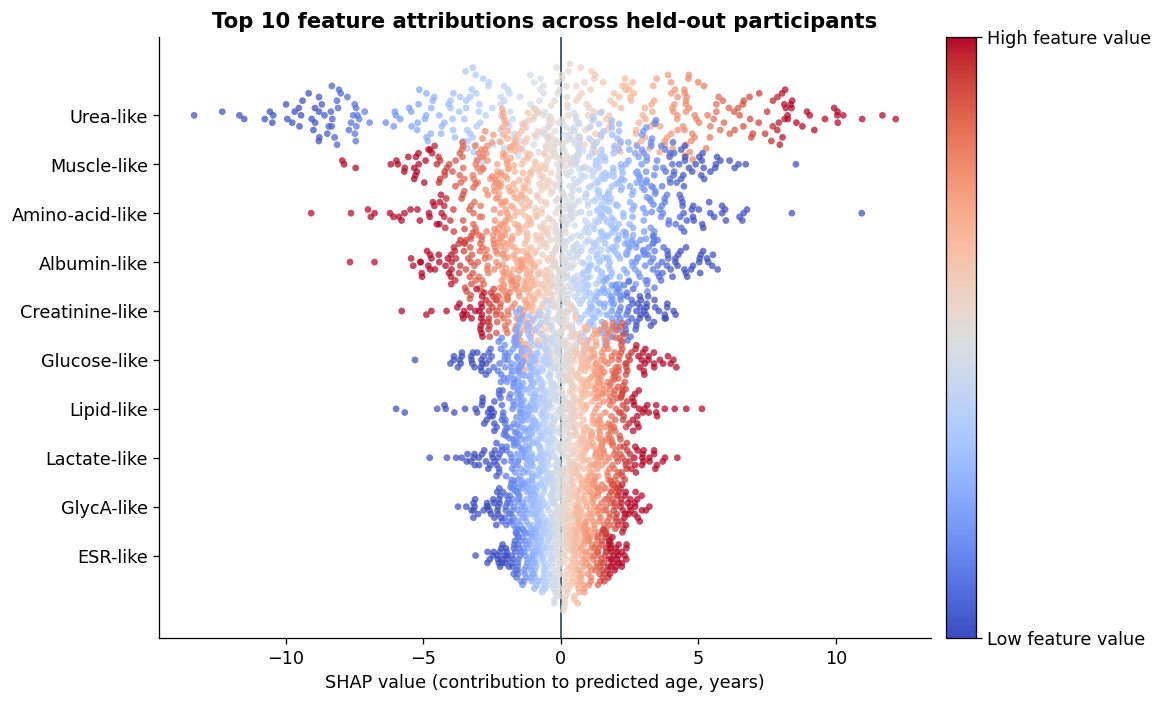

In [12]:
# Exact marginal SHAP values for the fitted standardized linear clock.
preprocessor, linear_model = clock[:-1], clock[-1]
Ztr = preprocessor.transform(Xtr)
Zte = preprocessor.transform(Xte)
background_mean = Ztr.mean(axis=0)
assert np.allclose(background_mean, 0)
phi_test = (Zte - background_mean) * linear_model.coef_
baseline = float(linear_model.intercept_ + background_mean @ linear_model.coef_)
assert np.allclose(baseline + phi_test.sum(axis=1), pred)

from matplotlib.colors import Normalize

feature_names = np.asarray(X.columns)
top10 = np.argsort(np.mean(np.abs(phi_test), axis=0))[-10:][::-1]

def swarm_offsets(values, step=.075, bins=26):
    """Stack nearby SHAP values vertically to make a dependency-style beeswarm."""
    edges = np.linspace(values.min(), values.max(), bins + 1)
    bin_id = np.clip(np.digitize(values, edges) - 1, 0, bins - 1)
    offsets = np.zeros(len(values))
    for group in (np.flatnonzero(bin_id == b) for b in range(bins)):
        sequence = np.empty(len(group))
        sequence[0::2] = np.arange((len(group) + 1) // 2)
        sequence[1::2] = -np.arange(1, len(group) // 2 + 1)
        offsets[group] = step * sequence
    return offsets

fig, ax = plt.subplots(figsize=(10, 6), layout="constrained")
for rank, feature_idx in enumerate(top10):
    row = len(top10) - 1 - rank
    values = Xte.iloc[:, feature_idx].to_numpy()
    low, high = np.quantile(values, [.05, .95])
    scaled_values = np.full(len(values), .5) if np.isclose(low, high) else np.clip((values - low) / (high - low), 0, 1)
    ax.scatter(phi_test[:, feature_idx], row + swarm_offsets(phi_test[:, feature_idx]),
               c=scaled_values, cmap="coolwarm", s=18, alpha=.72, edgecolors="none", rasterized=True)

ax.axvline(0, color=NAVY, lw=1, zorder=0)
ax.set(yticks=np.arange(len(top10)), yticklabels=feature_names[top10[::-1]],
       xlabel="SHAP value (contribution to predicted age, years)",
       title="Top 10 feature attributions across held-out participants")
colour_scale = plt.cm.ScalarMappable(norm=Normalize(0, 1), cmap="coolwarm")
colour_scale.set_array([])
colourbar = fig.colorbar(colour_scale, ax=ax, pad=.02)
colourbar.set_ticks([0, 1], labels=["Low feature value", "High feature value"])
finish(fig, "08_shap_beeswarm", alt="Beeswarm plot of the ten features with the largest mean absolute SHAP values across held-out synthetic participants.")

### SYNTHETIC LAB · Explain one fitted clock output

For a linear predictor and marginal masking, $\phi_j=\beta_j(z_j-\overline z_{j,train})$ for any covariance. P2 obtains the same formula for the conditional game only when features are independent (Prop. B.1, p. 23); with correlated Gaussian features P2 gives $\phi_i=B^TM_i(\Sigma)(x-\mu)$ (Prop. B.2, p. 24), which is what `linear_gaussian_game(..., conditional=True)` computes (verified in section 9). Our background is the training population after the fitted preprocessing; because the scaler was fitted on the training data, $\overline z_{train}=0$ and $\phi_j=\beta_jz_j$. Contributions are in years.

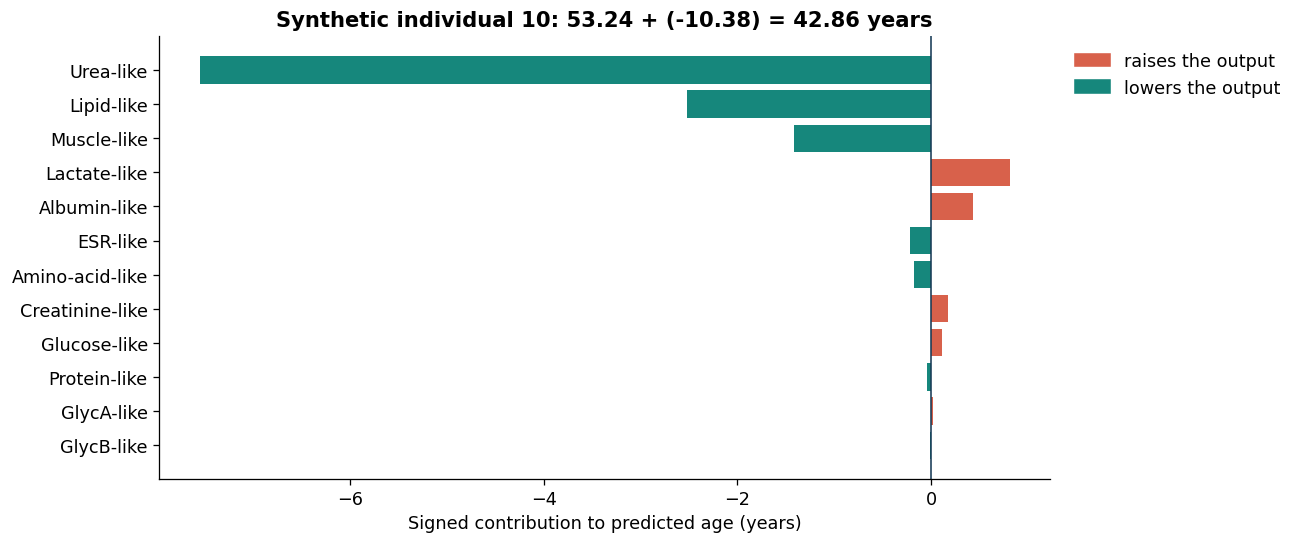

Chronological age 36.6; raw gap +6.2; reference distortion +3.7 years


In [13]:
preprocessor, linear_model = clock[:-1], clock[-1]
Ztr = preprocessor.transform(Xtr)
Zte = preprocessor.transform(Xte)
background_mean = Ztr.mean(axis=0)
assert np.allclose(background_mean, 0)
phi_test = (Zte-background_mean)*linear_model.coef_
baseline = float(linear_model.intercept_+background_mean@linear_model.coef_)
assert np.allclose(baseline+phi_test.sum(axis=1),pred)

person = 10  # Fixed in advance; change to another test-row position to explore.
contributions = phi_test[person]
order = np.argsort(np.abs(contributions))
fig, ax = plt.subplots(figsize=(10,5))
ax.barh(np.array(X.columns)[order],contributions[order],
        color=[CORAL if v>0 else TEAL for v in contributions[order]])
ax.axvline(0,color=NAVY,lw=1)
ax.legend(handles=SIGN_LEGEND, frameon=False, loc="upper left", bbox_to_anchor=(1.01, 1))
ax.set(xlabel="Signed contribution to predicted age (years)",
       title=f"Synthetic individual {person}: {baseline:.2f} + ({contributions.sum():.2f}) = {pred[person]:.2f} years")
finish(fig,"08_local_attributions")
print(f"Chronological age {ate.iloc[person]:.1f}; raw gap {raw_gap[person]:+.1f}; "
      f"reference distortion {distortion[person]:+.1f} years")

### Signed contributions, pathway magnitudes and grouped games

For a predefined group $H$, distinguish
$$\underbrace{\sum_{j\in H}\phi_j}_{\text{signed contribution}}\quad\text{from}\quad
\underbrace{\sum_{j\in H}|\phi_j|}_{\text{attribution magnitude}}.$$

P1 defines its SHAP-group score as the **sum of absolute individual SHAP values** (Methods, p. 13): it summarizes influence, not direction. Across groups that partition the features, signed sums reconstruct the prediction deviation; sums of magnitudes do not, and larger groups can accumulate more magnitude.

**A signed group sum is not, in general, the Shapley value of the grouped game.** Write $v=\sum_T d_T u_T$ with Harsanyi dividends $d_T=\sum_{S\subseteq T}(-1)^{|T|-|S|}v(S)$. Then $\phi_j=\sum_{T\ni j}d_T/|T|$: each synergy is split equally among its *features*, so group $H$ collects $\sum_T d_T|T\cap H|/|T|$, whereas the grouped game splits each synergy equally among the *groups* it touches. For an additive game (only singleton dividends, as in the linear marginal lab above) the two agree; for the conditional game below they differ.

**P1's groups.** P1's full group definitions are in its Extended Data Table 22, and Fig. 3 (p. 7) shows the members of every group. P1's groups overlap: albumin sits in both “Inflammation and immune activity” and “Structural integrity and systemic frailty”, and formic acid, serine and methionine each appear in two groups. Our teaching partition below avoids this double counting.

In [14]:
teaching_groups = {"Inflammation / protein": [0,1,2,3,11],
                   "Renal / muscle proxy": [4,5,10],
                   "Energy / amino acids / lipid": [6,7,8,9]}
assert sorted(j for group in teaching_groups.values() for j in group)==list(range(X.shape[1]))
group_table = pd.DataFrame({name:{"Signed sum (years)":contributions[idx].sum(),
                                "Sum of magnitudes (years)":np.abs(contributions[idx]).sum(),
                                "Number of features":len(idx)}
                           for name,idx in teaching_groups.items()}).T
group_table["Number of features"] = group_table["Number of features"].astype(int)
display(group_table.round(3))
assert np.isclose(group_table["Signed sum (years)"].sum(),pred[person]-baseline)

def harsanyi_dividends(game):
    '''Möbius inversion: d_T = sum over S ⊆ T of (-1)^{|T|-|S|} v(S), bit-mask order.'''
    game = np.asarray(game, dtype=float)
    d = np.zeros_like(game)
    for T in range(1, len(game)):
        S = T
        while True:
            d[T] += (-1)**(T.bit_count()-S.bit_count())*game[S]
            if S == 0:
                break
            S = (S-1) & T
    return d

# A three-factor conditional age game (reused by the rigidity lab in section 9).
factor_names = ["Inflammation factor", "Renal factor", "Energy factor"]
sigma = np.array([[1.,.8,.2],[.8,1.,.1],[.2,.1,1.]])
x = np.array([1.2,.8,-.5])
B_age = np.array([6.,4.,-3.])
age_game = linear_gaussian_game(B_age, x, sigma)[:,0]
d = harsanyi_dividends(age_game)
phi_from_dividends = [sum(d[T]/T.bit_count() for T in range(1,8) if T & (1<<j)) for j in range(3)]
assert np.allclose(phi_from_dividends, exact_shapley(age_game))
# Grouped (quotient) game with players G1 = {Inflammation, Renal} and G2 = {Energy}.
v_G1, v_G2, v_all = age_game[0b011], age_game[0b100], age_game[0b111]
quotient = [(v_G1 + v_all - v_G2)/2, (v_G2 + v_all - v_G1)/2]
phi_age = exact_shapley(age_game)
display(pd.DataFrame({"Sum of individual Shapley values": [phi_age[:2].sum(), phi_age[2]],
                      "Shapley value of the grouped game": quotient},
                     index=["{Inflammation, Renal}", "{Energy}"]).round(3))
print("A cancellation example: contributions [+4,-4] give signed sum 0 but magnitude 8.")

,Signed sum (years),Sum of magnitudes (years),Number of features
Inflammation / protein,0.188,0.721,5
Renal / muscle proxy,-8.787,9.143,3
Energy / amino acids / lipid,-1.779,3.624,4


,Sum of individual Shapley values,Shapley value of the grouped game
"{Inflammation, Renal}",10.279,10.4
{Energy},1.621,1.5


A cancellation example: contributions [+4,-4] give signed sum 0 but magnitude 8.


<a id="theorem"></a>
## 9 · The rigidity theorem: why multi-output SHAP must be coordinate-wise [P2]

*Why this is exciting:* a new theorem tells practitioners exactly what multi-output explanations can and cannot be [P2].

Now let $f:\mathbb R^n\to\mathbb R^m$ predict several quantities. Each coalition receives a **vector** $v(S)\in\mathbb R^m$. Impose efficiency, symmetry, dummy player and additivity in $\mathbb R^m$ (P2, Def. 2.7).


<div style="border-left:6px solid #183b56;background:#eef3f8;color:#1d3540;padding:12px 20px;border-radius:8px;margin:16px 0">

<span style="color:#183b56;font-weight:700;letter-spacing:1.5px;font-size:12px">THEOREM</span> **Rigidity (P2, Theorems 2.8–2.9 and Corollary 2.10, pp. 7–8)**

A vector-valued allocation that satisfies efficiency, symmetry, dummy player and additivity in $\mathbb R^m$ must be

$$\Phi_j(v)=\big(\phi_j(v_1),\ldots,\phi_j(v_m)\big):$$

the $k$-th output is explained by its own scalar game, and by nothing else. Coordinate-wise SHAP is therefore **not a convention but the only axiom-consistent choice** (“the unique consequence of enforcing classical Shapley fairness”, P2, p. 17).

**Corollary 2.10.** Any rule that couples outputs must violate at least one axiom. P2 §2.4 (pp. 9–10) stresses that this is conditional: coupling becomes possible only by scalarizing efficiency, relaxing additivity or adding preference structures over outputs, which is P2's open problem 1.

</div>

<div style="border-left:6px solid #5b4a8b;background:#f3f0f9;color:#1d3540;padding:12px 20px;border-radius:8px;margin:16px 0">

<span style="color:#5b4a8b;font-weight:700;letter-spacing:1.5px;font-size:12px">TRANSLATION</span> **Biological translation**

One explanation per output, in that output's units. A shared model can learn age, a metabolic score and sex together; the age explanation still allocates the age prediction and the risk explanation allocates the risk score. Shared training can change the learned age predictor, and therefore its explanation, but it cannot make the age explanation borrow credit from the risk output.

</div>

**Two dividends of rigidity.** (i) The theorem is a statement about the allocation operator on arbitrary vector games, so it holds whichever game (conditional, marginal or estimated) defines $v$: per-output allocation is forced for conditional and marginal SHAP alike. (ii) For any matrix $W$, $\Phi(Wv)=W\Phi(v)$: a composite score built *linearly* from the outputs is explained by the same combination of per-output explanations, and one set of coalition evaluations serves every linear readout. Nonlinear readouts (for example a sigmoid) need a new game.

**Two boundaries.** The theorem does not say the outputs are statistically independent. It also does not guarantee identical explanations for separately and jointly trained models: those are different functions and define different games. The open part for practice is how well a surrogate such as DeepExplainer approximates the chosen game; error bounds for vector-valued estimators are P2's open problem 5.

### Optional mathematical lens · A proof in four steps

For a nonempty coalition $T$, let $u_T(S)=1$ when $T\subseteq S$ and 0 otherwise. These *unanimity games* form a basis of scalar games with $v(\varnothing)=0$.

1. Consider the vector basis game $u_T e_k$, supported in one output direction.
2. Players outside $T$ are dummies, so their allocations are zero. Players in $T$ are symmetric, so each receives the same vector $a$.
3. Vector efficiency gives $|T|a=e_k$. Thus $a=e_k/|T|$: no other output coordinate appears.
4. Every vector game has a unique expansion $v=\sum_{T\neq\varnothing}\sum_k d_{T,k}\,u_Te_k$ with Harsanyi dividends $d_{T,k}=\sum_{S\subseteq T}(-1)^{|T|-|S|}v_k(S)$. Additivity then forces $\Phi_j(v)=\sum_{T\ni j}d_T/|T|\in\mathbb R^m$, which is the Shapley formula applied coordinate by coordinate (**uniqueness**). Conversely, the coordinate-wise rule satisfies all four axioms (**existence**).

The basis step matters: efficiency, symmetry and additivity alone would allow compensating positive and negative leakage between players; the lab below builds such a leaky rule. [P2, Appendix A, pp. 19–22; Step 1 of the proof of Thm 2.8, p. 20; Lemmas A.1–A.2, p. 21]

### SYNTHETIC LAB · Check the axioms numerically and watch a leaky rule fail

We use the three standardized molecular factors of section 8 (positive-definite Gaussian covariance) and a known linear predictor with three outputs: age-like years, a dimensionless risk score and a classification logit. The risk score is not MetSCORE. The classification coordinate is in **log-odds**; applying a sigmoid requires a new explanation on the probability scale.

The first checks confirm **existence**: the coordinate-wise rule is efficient and commutes with linear readouts. Those checks cannot fail by construction. The informative test is the second one: a “leaky” rule that is efficient, symmetric and linear, yet moves credit between outputs, necessarily **breaks the dummy axiom**.

,Age-like (years),Risk-like (score units),Class logit (log-odds)
Inflammation factor,7.171,0.513,0.995
Renal factor,3.108,0.251,0.290
Energy factor,1.621,0.046,-0.564


Efficiency error: 1.1102230246251565e-16


,Age-like (years),Risk-like (score units),Class logit (log-odds)
Leaky rule on u_T e_1,,,
Factor 1 (in T),0.5,0.167,0.0
Factor 2 (in T),0.5,0.167,0.0
Factor 3 (dummy),0.0,-0.333,0.0


Efficiency, symmetry and linearity alone allow cross-output leakage; the dummy axiom removes it.


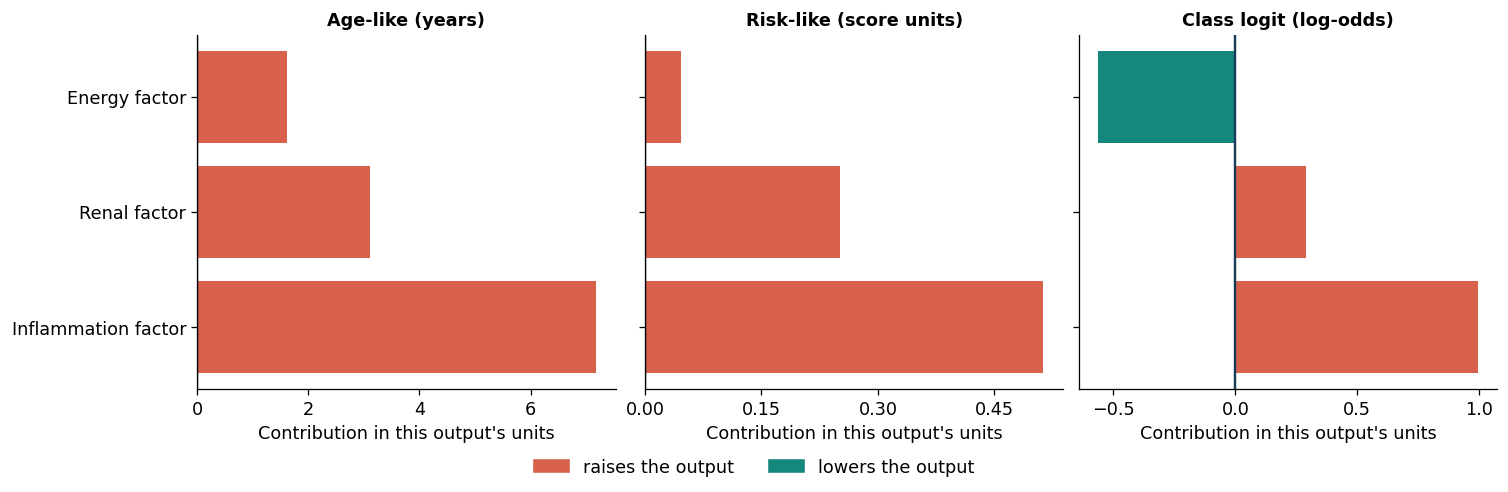

In [15]:
output_names = ["Age-like (years)", "Risk-like (score units)", "Class logit (log-odds)"]
B = np.column_stack([B_age, [.3,.5,-.1], [1.2,-.4,.8]])   # rows: factors; columns: outputs
base = np.array([50.,.4,-.2])
assert np.linalg.eigvalsh(sigma).min()>0
game = linear_gaussian_game(B,x,sigma,conditional=True)
phi_vector = exact_shapley(game)
phi_separate = np.column_stack([exact_shapley(game[:,k]) for k in range(3)])
# Existence checks (true by construction of the coordinate-wise rule):
assert np.allclose(phi_vector,phi_separate)
assert np.allclose(phi_vector.sum(axis=0),game[-1])
assert np.allclose(base+phi_vector.sum(axis=0),base+x@B)
w = np.array([1.,2.,.5])                          # an arbitrary linear readout, not a clinical score
assert np.allclose(exact_shapley(game@w),phi_vector@w)
display(pd.DataFrame(phi_vector,index=factor_names,columns=output_names).round(3))
print("Efficiency error:",np.max(np.abs(phi_vector.sum(axis=0)-game[-1])))

# The informative test: a leaky rule keeps output 1 untouched but adds to output 2 a
# zero-sum term built from output 1 (each player's excess over an equal share of v_1(N)).
def leaky(v):
    Phi = exact_shapley(v)
    shift = np.zeros(v.shape[1]); shift[1] = 1.
    return Phi + np.outer(Phi[:,0] - v[-1,0]/Phi.shape[0], shift)

assert np.allclose(leaky(game).sum(axis=0), game[-1])      # still efficient
unanimity = np.zeros((8,3))
unanimity[[m for m in range(8) if m & 0b011 == 0b011], 0] = 1.   # u_{T} e_1 with T = {factor 1, factor 2}
leak = leaky(unanimity)
assert np.allclose(leak.sum(axis=0), unanimity[-1])         # efficient on the basis game too
assert np.allclose(exact_shapley(unanimity)[2], 0)          # coordinate-wise rule: dummy gets zero
assert np.allclose(leak[:,0], exact_shapley(unanimity)[:,0])  # output 1 itself is untouched
assert not np.allclose(leak[2], 0)                          # leaky rule: the dummy player gets credit
display(pd.DataFrame(leak, index=["Factor 1 (in T)","Factor 2 (in T)","Factor 3 (dummy)"],
                     columns=output_names).round(3).rename_axis("Leaky rule on u_T e_1"))
print("Efficiency, symmetry and linearity alone allow cross-output leakage; the dummy axiom removes it.")

fig, axes = plt.subplots(1,3,figsize=(13,4.2),layout="constrained")
for k,ax in enumerate(axes):
    ax.barh(factor_names,phi_vector[:,k],color=[CORAL if z>0 else TEAL for z in phi_vector[:,k]])
    ax.axvline(0,color=NAVY); ax.set_title(output_names[k],fontsize=11)
    ax.set_xlabel("Contribution in this output's units")
    ax.xaxis.set_major_locator(plt.MaxNLocator(4))
    if k: ax.set_yticklabels([])
fig.legend(handles=SIGN_LEGEND, loc="outside lower center", ncol=2, frameon=False)
finish(fig,"09_vector_shap")

In [16]:
# Verifying P2, Proposition B.2: phi_i = B^T M_i(Sigma) (x - mu), here with mu = 0.
p = len(x)
def embedded_A(S):
    '''A_S = Sigma[:,S] Sigma[S,S]^{-1}, embedded as an n x n matrix with zero columns outside S.'''
    A = np.zeros((p,p))
    if S:
        A[:, S] = sigma[:, S] @ np.linalg.inv(sigma[np.ix_(S,S)])
    return A
for i in range(p):
    others = [j for j in range(p) if j != i]
    M_i = sum(math.factorial(r)*math.factorial(p-r-1)/math.factorial(p)
              * (embedded_A(sorted(S+(i,))) - embedded_A(list(S)))
              for r in range(p) for S in itertools.combinations(others, r))
    assert np.allclose(phi_vector[i], B.T @ M_i @ x)
print("Proposition B.2 reproduced for all three factors and all three outputs.")

Proposition B.2 reproduced for all three factors and all three outputs.


### Interactive window · Three outputs, one explanation each

Move the correlation between the inflammation and renal factors, or switch between the conditional and marginal games. The credit shifts between the two factors in every output, yet each output's bars always sum to that output's prediction, and no output borrows credit from another. That is the rigidity theorem at work. (Static preview below; the controls are live in a running kernel.)

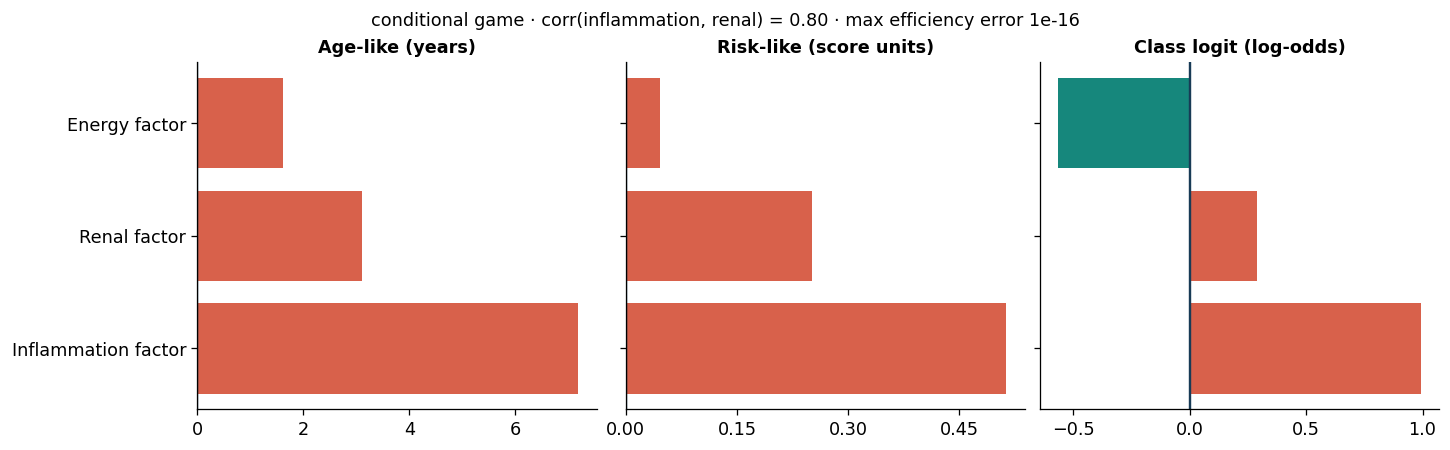

In [17]:
def multi_output_figure(rho=.8, conditional=True):
    covariance = np.array([[1.,rho,.2],[rho,1.,.1],[.2,.1,1.]])
    g = linear_gaussian_game(B, x, covariance, conditional)
    phi = exact_shapley(g)
    fig, axes = plt.subplots(1,3,figsize=(12.5,3.8),layout="constrained")
    for k,ax in enumerate(axes):
        ax.barh(factor_names, phi[:,k], color=[CORAL if z>0 else TEAL for z in phi[:,k]])
        ax.axvline(0,color=NAVY); ax.set_title(output_names[k],fontsize=11)
        ax.xaxis.set_major_locator(plt.MaxNLocator(4))
        if k: ax.set_yticklabels([])
    fig.suptitle(f"{'conditional' if conditional else 'marginal'} game · corr(inflammation, renal) = {rho:.2f}"
                 f" · max efficiency error {np.abs(phi.sum(0)-g[-1]).max():.0e}", fontsize=11)
    return fig

controls = ({"rho": widgets.FloatSlider(value=.8, min=0, max=.95, step=.05, description="ρ",
                                        continuous_update=False),
             "conditional": widgets.Checkbox(value=True, description="Conditional game")}
            if HAS_WIDGETS else None)
live_window(multi_output_figure, controls, rho=.8, conditional=True)

### Short video 3 · Averaging over orders of revelation

**Watch for:** each order assigns different increments, but every order ends at the same total. **Transcript:** Three factors (inflammation, renal, energy) enter a coalition one at a time, and the chart accumulates the increments for the age-like output of a three-factor conditional Gaussian game (the one used in the rigidity lab of section 9). After all six orders, the average assigned to each factor is its exact Shapley value: 7.17, 3.11 and 1.62 years, the exact age-output Shapley values of the rigidity lab. The same operation is performed for every coordinate of a vector output; shared model evaluations can compute them together.

In [18]:
video_path = ROOT / "assets" / "videos" / "03_shapley_orders.mp4"
if video_path.exists():
    display(Video(str(video_path), embed=True, width=850,
                  html_attributes='controls preload="metadata" aria-label="Animation of Shapley values averaged over feature orders"'))
else:
    print("Video asset not present. Use the exact coalition code and transcript above.")
assert np.allclose(phi_vector[:,0].round(2), [7.17, 3.11, 1.62])   # numbers quoted in the transcript

### Stability: what is guaranteed, and where the open questions start

P2, Proposition 2.11 (p. 9), proves
$$\|\Phi(u)-\Phi(v)\|_{A,\infty}\leq
\|u-v\|_{\Delta,\infty}\leq 2\|u-v\|_{G,\infty},$$
where the allocation norm is the largest absolute feature/output difference, the game norm the largest coalition/output difference, and the marginal seminorm the largest difference of coalition increments. *Why?* Each attribution is a weighted average of increments with nonnegative weights summing to one; each increment contains two game values.¹

P2, Proposition 2.13 (p. 11), transfers this to predictors $f,g$ with the same background:
$$\|\Phi(f;x)-\Phi(g;x)\|_{A,\infty}\le\|v_f-v_g\|_{\Delta,\infty},\qquad
\|\Phi(f;x)-\Phi(g;x)\|_{A,\infty}\le 2\|f-g\|_{L^\infty(\mu)}.$$
For the conditional game, $v_f(S\cup j)-v_f(S)-[v_g(S\cup j)-v_g(S)]=\mathbb E[h\mid X_{S\cup j}]-\mathbb E[h\mid X_S]$ with $h=f-g$: closeness on the data distribution suffices. Two technical points: for a continuous $\mu$ the full coalition involves $f(x)-g(x)$ at a single $\mu$-null point, so the $L^\infty(\mu)$ bound holds for $\mu$-almost every $x$ (or everywhere for continuous $f,g$ with $x$ in the support), and conditional expectations need a fixed regular version (P2, p. 10). For **marginal masking** the same argument needs $\sup|f-g|$ over the product of the marginals, i.e. off the data manifold, where two clocks that agree on real profiles can explain very differently (recall the $(1,-1)$ prediction in section 7).

**Open question for mathematicians (our addition, not a P2 claim).** P2's experiments use DeepExplainer, which approximates a background-based game. Turning the Table-4 agreement of [section 10.2](#results-p2) into a certificate would require estimating $\|v_f-v_g\|_{\Delta,\infty}$ from data and bounding the approximation error of the explainer; P2 notes (p. 11) that its results “apply to the exact Shapley operator”.

¹ For centered games the combined bound $\|\Phi(u)-\Phi(v)\|_{A,\infty}\le2\|u-v\|_{G,\infty}$ sharpens to $(2-1/p)\|u-v\|_{G,\infty}$, because the empty-coalition increment (weight $1/p$) involves only one game value.

In [19]:
# Exhaustively check the finite-game bound in this small example.
srng = np.random.default_rng(SEED+4)
epsilon = .15
perturbation = srng.uniform(-epsilon,epsilon,size=game.shape)
perturbation[0] = 0  # Both games remain centered.
game2 = game+perturbation
game_distance = np.max(np.abs(game2-game))
allocation_distance = np.max(np.abs(exact_shapley(game2)-exact_shapley(game)))
marginal_distance = max(
    np.max(np.abs(perturbation[mask | (1<<j)]-perturbation[mask]))
    for j in range(3) for mask in range(8) if not mask & (1<<j))
assert allocation_distance <= marginal_distance+1e-12
assert marginal_distance <= 2*game_distance+1e-12
display(pd.Series({"Observed allocation difference":allocation_distance,
                   "Marginal bound":marginal_distance,
                   "Twice game sup-norm":2*game_distance}).to_frame("Maximum absolute difference"))

,Maximum absolute difference
Observed allocation difference,0.072899
Marginal bound,0.244204
Twice game sup-norm,0.272189


### SYNTHETIC LAB · A trainable shared representation

We fit **two continuous tasks** with a small shared MLP and compare two separate MLPs. The second target is a made-up metabolic score built from synthetic features; it is deliberately correlated with age and is neither MetSCORE nor an independent health outcome. Unlike P2, this compact exercise has no classification head and no DeepExplainer; section 9 already showed exact attribution for a logit.

Inputs and targets are standardized on training observations; predictions return to original units. We report parameter counts and epochs instead of wall-clock time, which at this scale is at timer resolution and machine-dependent. [API: [MLPRegressor](https://scikit-learn.org/stable/modules/generated/sklearn.neural_network.MLPRegressor.html), [TransformedTargetRegressor](https://scikit-learn.org/stable/modules/generated/sklearn.compose.TransformedTargetRegressor.html)]

In [20]:
from sklearn.neural_network import MLPRegressor
from sklearn.compose import TransformedTargetRegressor

mrng = np.random.default_rng(SEED+5)
synthetic_score = (.35*X["Glucose-like"]+.25*X["Lipid-like"]+
                   .15*X["ESR-like"]+.20*np.tanh(X["Urea-like"])+
                   mrng.normal(0,.15,len(X)))
Y = np.column_stack([age,synthetic_score])
Ytr, Yte = Y[train_ids],Y[test_ids]

def new_mlp(seed):
    return TransformedTargetRegressor(
        regressor=make_pipeline(StandardScaler(), MLPRegressor(
            hidden_layer_sizes=(20,), activation="relu", solver="adam",
            alpha=.1, max_iter=450, learning_rate_init=.003,
            tol=.001, n_iter_no_change=25, random_state=seed)),
        transformer=StandardScaler())

def n_parameters(model):
    mlp = model.regressor_[-1]
    return sum(w.size for w in mlp.coefs_) + sum(b.size for b in mlp.intercepts_)

joint_model = new_mlp(SEED).fit(Xtr,Ytr)
separate_models = [new_mlp(SEED+k).fit(Xtr,Ytr[:,k]) for k in range(2)]
joint_prediction = joint_model.predict(Xte)
separate_prediction = np.column_stack([m.predict(Xte) for m in separate_models])
multitask_rows=[]
for name,prediction in [("Joint",joint_prediction),("Separate",separate_prediction)]:
    for k,target in enumerate(["Age (years)","Synthetic score (arbitrary units)"]):
        multitask_rows.append({"Model":name,"Target":target,
                              "RMSE":np.sqrt(mean_squared_error(Yte[:,k],prediction[:,k])),
                              "R²":r2_score(Yte[:,k],prediction[:,k])})
display(pd.DataFrame(multitask_rows).set_index(["Model","Target"]).round(3))
print(f"Parameters: joint {n_parameters(joint_model)} vs separate total "
      f"{sum(n_parameters(m) for m in separate_models)}; epochs: joint {joint_model.regressor_[-1].n_iter_}, "
      f"separate {[m.regressor_[-1].n_iter_ for m in separate_models]}.")
print("One seed and fixed settings: an illustration, not a controlled efficiency benchmark.")

RMSE     R²
Model    Target                                         
Joint    Age (years)                        7.173  0.861
         Synthetic score (arbitrary units)  0.164  0.946
Separate Age (years)                        7.177  0.861
         Synthetic score (arbitrary units)  0.163  0.947

Parameters: joint 302 vs separate total 562; epochs: joint 46, separate [41, 39].
One seed and fixed settings: an illustration, not a controlled efficiency benchmark.


**Interpretation task.** Does joint training help both outputs here? The rigidity theorem cannot answer that: it characterizes allocation for a given game, while model selection and generalization are separate problems. Replacing the second target with noise gives a useful negative-transfer experiment (Exercise E7).

For a real benchmark, fix splits and tuning budgets, vary seeds, report each task's uncertainty and calibration, record parameter counts and hardware, and inspect the Pareto trade-off between losses. If an auxiliary score is itself built from the input biomarkers, predicting it may mainly learn that construction; it is not independent validation of aging biology.

<div style="background:#123047;color:white;padding:12px 20px;border-radius:8px;margin:28px 0 8px"><span style="color:#83d9c4;letter-spacing:2px;font-size:13px;font-weight:700">PART V · RESULTS ACHIEVED</span><span style="color:#e4eef3"> — what the two papers established</span></div>

<a id="results-p1"></a>
## 10 · Results achieved

### 10.1 · P1: the MetAge clock and its disease maps

**REPORTED [P1] · Data and design.** The reference resource contains **29,390 individuals aged 7–106**, from up to seven studies. Model development uses an age- and sex-balanced subset of **8,640** (five age strata, p. 13), with 20% held out as an independent test set and five-fold cross-validation on the remaining 80%. An external Austrian cohort (**121 participants**, different country and laboratory) and **3,882 patients** in eleven disease cohorts complete the design. The age learner is a TPOT-derived stack of Ridge and ExtraTrees after standardization. [P1, pp. 3–6, 12–13]

| Representation | Test Pearson $r$ | Test RMSE (years) | Reported condition number $\kappa$ |
|---|---:|---:|---:|
| NOESY bins | 0.93 | 6.5 | ≈ 15,000 |
| CPMG | 0.92 | 6.8 | not reported |
| Raw FID (time domain) | 0.89 | 8.6 | not reported |
| Initial 74 biomarkers | 0.89 | 8.6 | ≈ 38 |
| **Curated 75 biomarkers** | **0.88** | **8.7** | **≈ 16** |
| Automated IVDr reports (143 parameters; lipoprotein subfraction cross-correlation) | 0.86 | 9.3 | ≈ 180 |

Sources: P1, pp. 4–5. These are reported results, not a fresh benchmark; P1 does not give uncertainty on the differences. P1 also checks the distortion on 1,000 negative-control resamplings of 1,000 healthy samples each, drawn from the 20,750 samples set aside during age balancing, and finds “exceptional structural alignment” with matched references (pp. 6, 13).

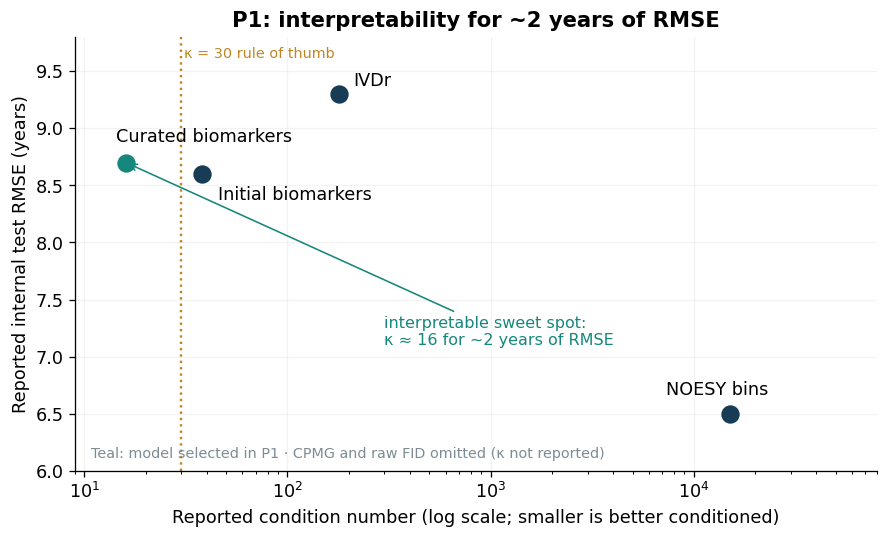

In [21]:
# REPORTED values only (P1, pp. 4-5). No fabricated participants or error bars.
p1 = pd.DataFrame({"Representation": ["NOESY bins", "Initial biomarkers", "Curated biomarkers", "IVDr"],
                   "RMSE": [6.5, 8.6, 8.7, 9.3], "kappa": [15000, 38, 16, 180]})
offsets = {"Curated biomarkers": (-6, 13), "Initial biomarkers": (10, -16), "IVDr": (9, 5), "NOESY bins": (-40, 12)}
fig, ax = plt.subplots(figsize=(9, 4.9))
ax.axvline(30, ls=":", color=GOLD)
ax.text(31, 9.62, "κ = 30 rule of thumb", color=GOLD, fontsize=9)
for row in p1.itertuples():
    ax.scatter(row.kappa, row.RMSE, s=110, color=TEAL if row.kappa==16 else NAVY, zorder=3)
    ax.annotate(row.Representation, (row.kappa,row.RMSE), xytext=offsets[row.Representation],
                textcoords="offset points", ha="left")
ax.annotate("interpretable sweet spot:\nκ ≈ 16 for ~2 years of RMSE", (16, 8.7), xytext=(300, 7.1),
            arrowprops={"arrowstyle": "->", "color": TEAL}, color=TEAL, fontsize=10)
ax.text(0.02, 0.03, "Teal: model selected in P1 · CPMG and raw FID omitted (κ not reported)",
        transform=ax.transAxes, fontsize=9, color=GREY)
ax.set(xscale="log", xlim=(9,80000), ylim=(6,9.8),
       xlabel="Reported condition number (log scale; smaller is better conditioned)",
       ylabel="Reported internal test RMSE (years)", title="P1: interpretability for ~2 years of RMSE")
ax.grid(alpha=.15)
finish(fig, "02_p1_tradeoff")

**Reading an original study figure.** Below is **P1, Figure 2** (PDF p. 6), reproduced from [P1]. Panel a: internal test predictions, R = 0.884, RMSE 8.68 y; in P1's words, “the diagonal line represents the identity line, illustrating the minimal regression to the mean”. **A teaching point:** with R = 0.884, the section-3 theorem implies that even an optimal clock has slope ≈ R² ≈ 0.78, and panel a indeed shows the usual flattening (predictions near 30 y at age 20 and below 90 y at age 100). P1's improvement is relative to earlier NMR clocks, and the remaining age trend is exactly what the reference-line distortion removes. Panel b: SHAP beeswarm (one point per sample and feature; blue = low, red = high feature value); low albumin and high ESR push predicted age up and dominate. Panel c: external Austrian cohort (red; R = 0.81, RMSE 12.2 y) against its age-matched reference (blue; R = 0.89, RMSE 9.8 y). Compare the slope in panel a with the shrinkage window of section 6.

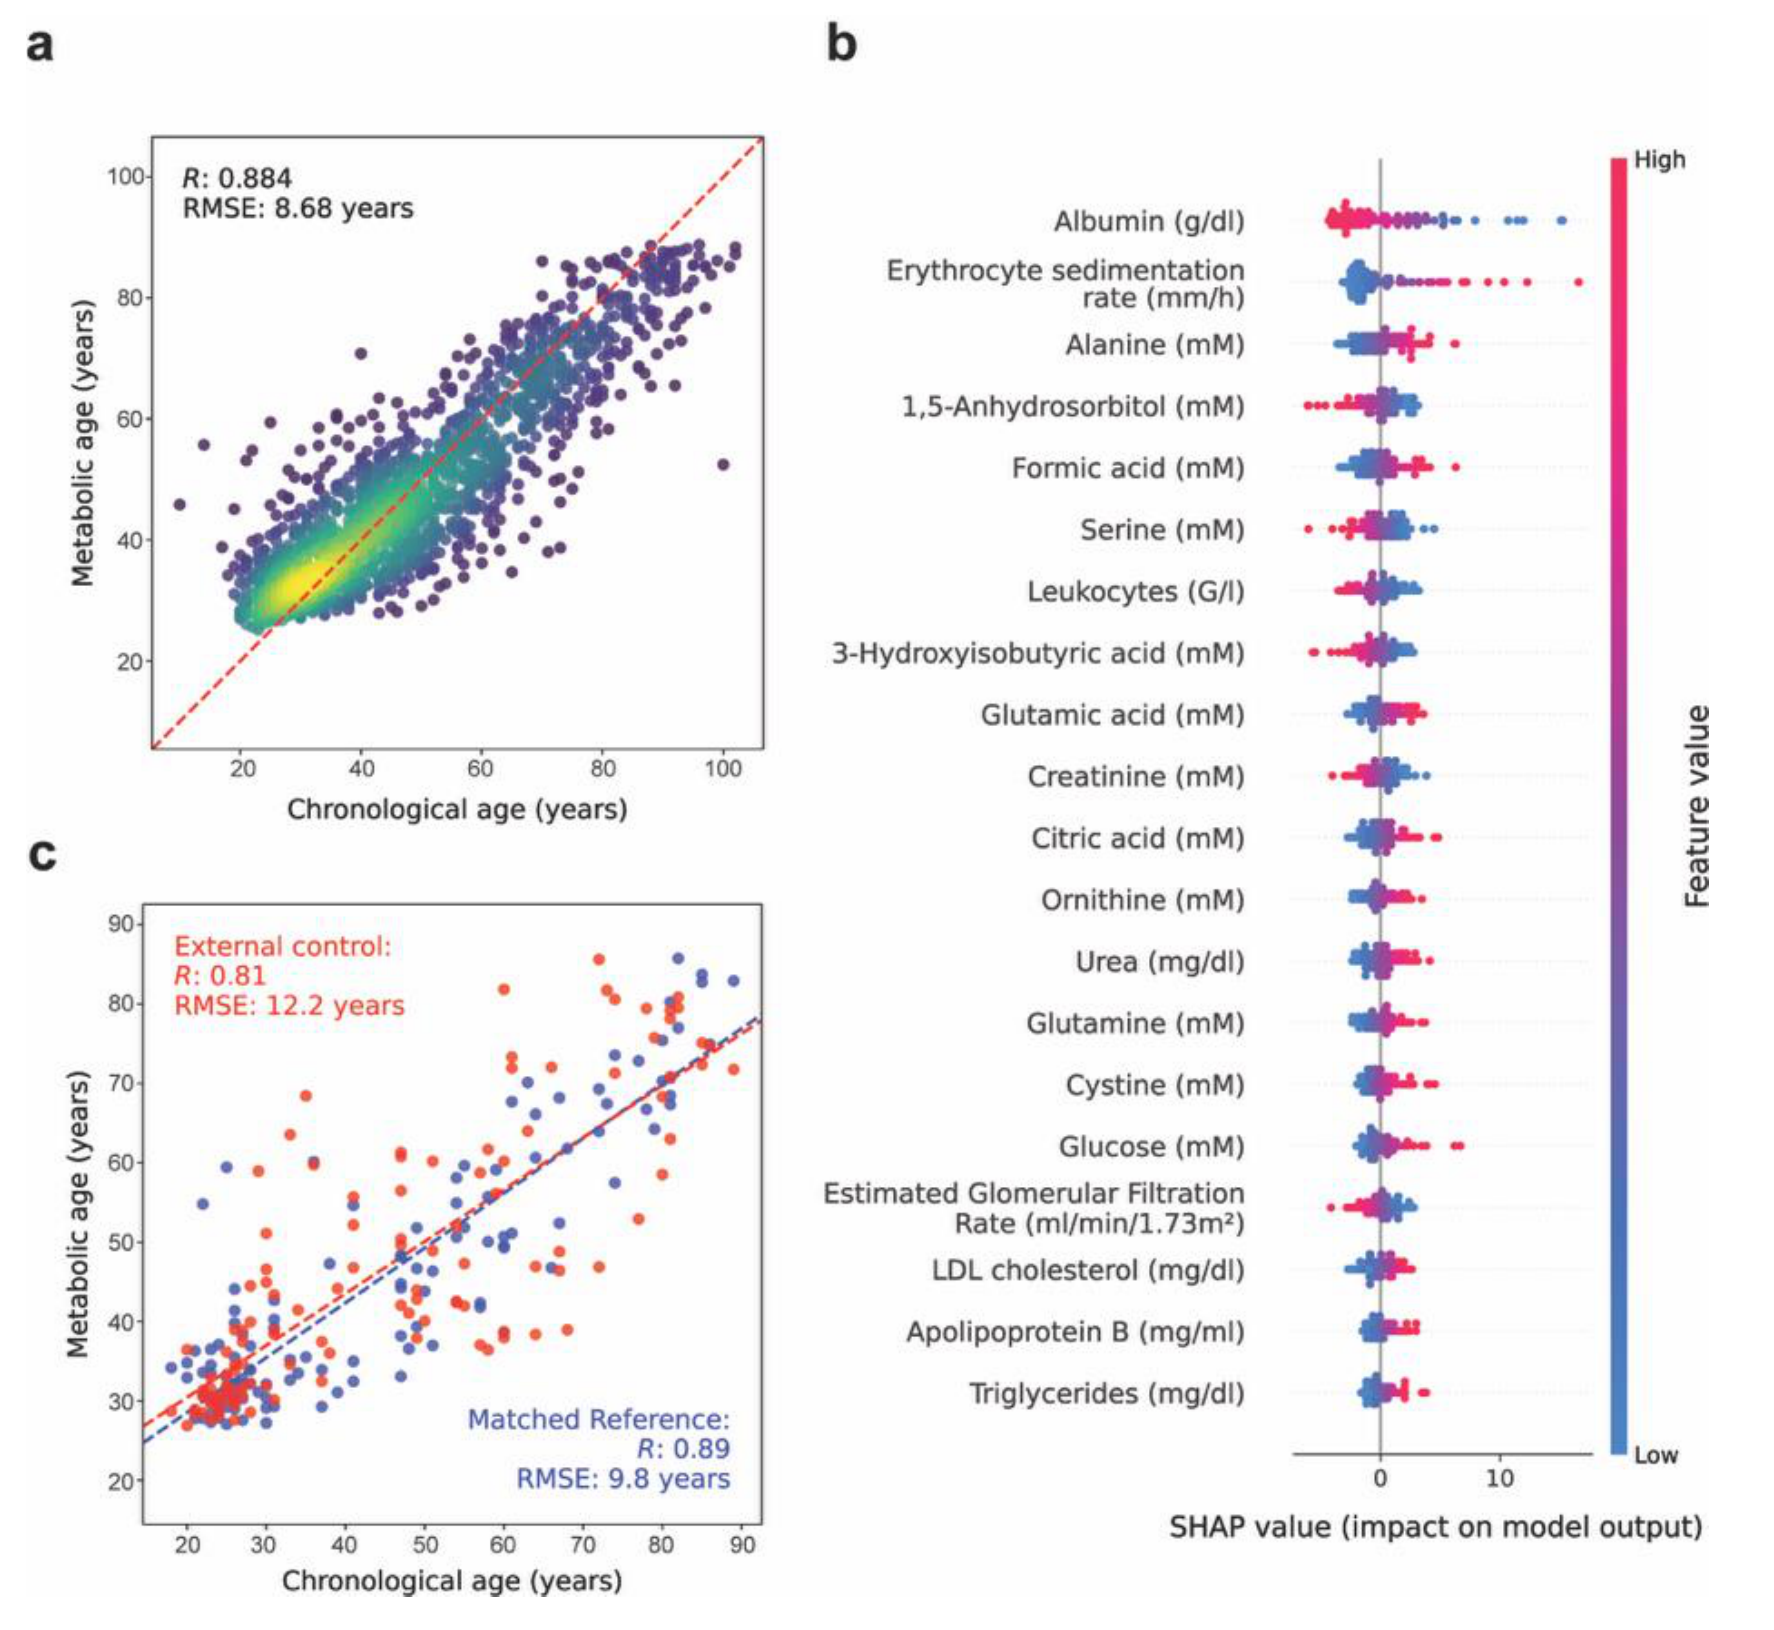

In [22]:
figure2 = FIGURES / "p1_original_figure2.png"
if figure2.exists():
    display(Image(filename=str(figure2), width=900,
                  alt="P1 Figure 2: internal prediction scatter, biomarker SHAP beeswarm, and external Austrian validation"))
else:
    print("See P1, Fig. 2, PDF p. 6 (run tools/extract_p1_figure.py to recreate the excerpt).")

**External validation and sex.** P1 interprets the Kolmogorov–Smirnov $p=0.1$ for Austria as showing no difference between populations (p. 6). Statistically this is a failure to reject: the Austrian distortion is 1.9 ± 9.7 y against 0 ± 5.6 y for its matched reference (Fig. 4m) and the RMSE is 12.2 against 9.8 y (Fig. 2c). The clock transfers to an independent laboratory with moderately larger error; formal equivalence testing and larger external cohorts are an open problem.

A **single unified model** works for both sexes: females r = 0.909, RMSE 8.3 y (female-only model 0.908 / 8.2); males r = 0.850, RMSE 9.0 y (male-only model 0.877 / 8.5). Kidney markers (urea, eGFR) matter more in women, glycemic markers (alanine, 1,5-anhydrosorbitol) more in men, and albumin and ESR lead in both. [P1, pp. 6–7, 10] Whether to model groups jointly or separately is a question both papers address: P1 for sex-specific clocks, P2 for joint prediction of age, MetSCORE and sex (10.2).

**The biological signature (grouped SHAP, Fig. 3, p. 7).** Share of the total grouped |SHAP| magnitude:

| Inflammation & immune activity | Nitrogen homeostasis | Energy metabolism | Structural integrity & frailty | Kidney function & nitrogen waste | One-carbon & methylation | Redox | Lipoprotein & CV risk | Muscle & BCAA | Hepatic clearance | Exposome | Others |
|---:|---:|---:|---:|---:|---:|---:|---:|---:|---:|---:|---:|
| 16.9% | 13.4% | 10.1% | 9.6% | 9.0% | 8.9% | 6.6% | 6.2% | 5.8% | 4.3% | 4.1% | 4.9% |

Individually, albumin and ESR have the largest mean |SHAP| (3.1 and 2.4 y), about twice alanine (1.6 y) and 1,5-anhydrosorbitol (1.4 y) (p. 7). P1 reads this as **inflammaging**: the model prefers albumin (a negative acute-phase reactant) and ESR over the more transient C-reactive protein, because they give a time-integrated readout of systemic inflammation (p. 10). Remember that P1's groups overlap (section 8), so the percentages count albumin twice.

### REPORTED [P1, Fig. 4, p. 8] · Every disease cohort is shifted toward older profiles

For each cohort, metabolic distortion is compared with an age-matched reference (sex-matched as well for PRC). All eleven comparisons are significant by the K–S test; the two negative controls are not. [P1, pp. 7–8]

| Cohort | n | Distortion, mean ± SD (y) | Matched reference (y) | K–S p |
|---|---:|---:|---:|---:|
| FLU · influenza | 158 | 17.5 ± 12.4 | 0 ± 7.6 | 2e-36 |
| MASLD · steatotic liver disease | 160 | 12.7 ± 11.7 | 0 ± 6.6 | 3e-24 |
| PSO · psoriasis | 226 | 9.7 ± 9.4 | 0 ± 6.5 | 2e-28 |
| COV · COVID-19 | 470 | 9.2 ± 11.3 | 0 ± 7.3 | 4e-35 |
| IBD · inflammatory bowel disease | 310 | 8.3 ± 12.6 | 0 ± 5.8 | 1e-20 |
| ALS · amyotrophic lateral sclerosis | 63 | 7.6 ± 8.4 | 0 ± 6.3 | 3e-7 |
| CVD · later cardiovascular event | 59 | 7.6 ± 8.3 | 0 ± 6.7 | 6e-6 |
| CKD · chronic kidney disease | 828 | 7.5 ± 14.4 | 0 ± 7.2 | 6e-61 |
| MetS · metabolic syndrome | 660 | 5.5 ± 10.1 | 0 ± 7.2 | 2e-29 |
| PRC · prostate cancer | 717 | 4.4 ± 9.3 | 0 ± 7.9 | 1e-17 |
| LCOV · long COVID | 231 | 2.8 ± 8.5 | 0 ± 6.8 | 1e-3 |
| *ITCL · internal test control* | 800* | 0.1 ± 6.5 | 0 ± 6.2 | 0.22 |
| *ETCL · external Austrian control* | 121 | 1.9 ± 9.7 | 0 ± 5.6 | 0.10 |

Values read from the panels of P1, Fig. 4. \*n = 800 as shown in Fig. 4l. A group shift is not individual predictive utility: the SDs show wide overlap between patients and references.

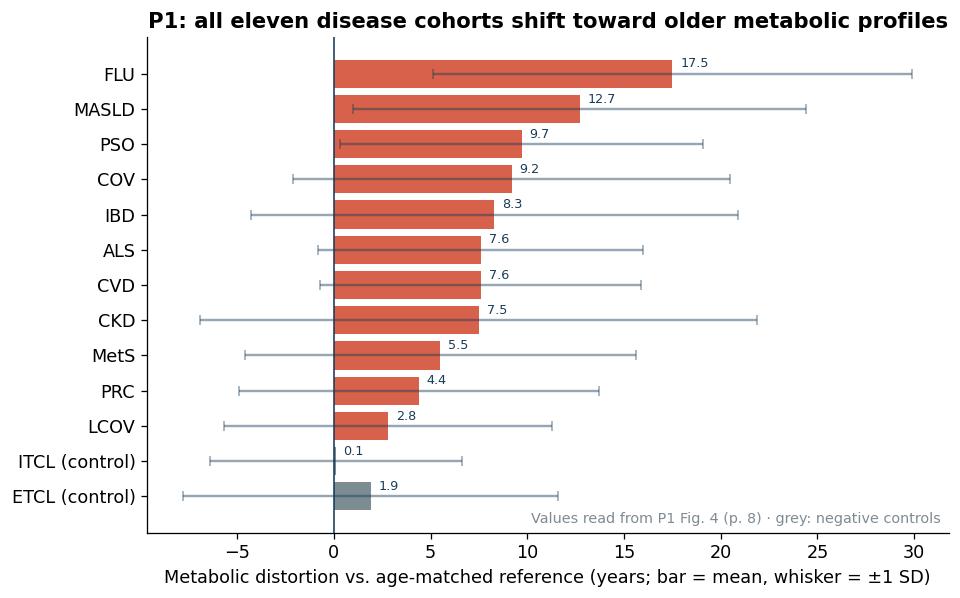

In [23]:
# REPORTED values read from P1, Fig. 4 (p. 8): cohort, n, mean distortion, SD.
fig4 = pd.DataFrame([
    ("FLU",158,17.5,12.4), ("MASLD",160,12.7,11.7), ("PSO",226,9.7,9.4), ("COV",470,9.2,11.3),
    ("IBD",310,8.3,12.6), ("ALS",63,7.6,8.4), ("CVD",59,7.6,8.3), ("CKD",828,7.5,14.4),
    ("MetS",660,5.5,10.1), ("PRC",717,4.4,9.3), ("LCOV",231,2.8,8.5),
    ("ITCL (control)",800,0.1,6.5), ("ETCL (control)",121,1.9,9.7)],
    columns=["Cohort","n","Mean distortion","SD"])
assert fig4.n[:11].sum() == 3882          # the eleven disease cohorts add up to P1's 3,882 donors
plot = fig4.iloc[::-1]
colors = [GREY if "control" in c else CORAL for c in plot.Cohort]
fig, ax = plt.subplots(figsize=(9, 5.6))
ax.barh(plot.Cohort, plot["Mean distortion"], xerr=plot.SD, color=colors,
        error_kw={"ecolor": NAVY, "alpha": .45, "capsize": 3})
ax.axvline(0, color=NAVY, lw=1)
for yy, (m, n) in enumerate(zip(plot["Mean distortion"], plot.n)):
    ax.text(m + .4, yy + .18, f"{m:.1f}", fontsize=8, color=NAVY)
ax.set(xlabel="Metabolic distortion vs. age-matched reference (years; bar = mean, whisker = ±1 SD)",
       title="P1: all eleven disease cohorts shift toward older metabolic profiles")
ax.text(.99, .02, "Values read from P1 Fig. 4 (p. 8) · grey: negative controls", transform=ax.transAxes,
        ha="right", fontsize=9, color=GREY)
finish(fig, "11_p1_disease_distortion")

### REPORTED [P1, pp. 8–11] · Disease-specific signatures

- **Three axes of distortion** (PCA of cohort |SHAP| profiles, Fig. 5): a **renal** axis (eGFR and uremic toxins such as urea, myo-inositol and urate), an **inflammatory** axis (albumin, ESR, C-reactive protein) that isolates COV and FLU, and a **strictly metabolic** axis (glutamic acid, sarcosine) that characterizes MASLD. The Austrian control is closest to the reference; CKD (patients on dialysis) is farthest. [pp. 9, 11]
- **Acute infection and active inflammation:** in FLU, COV and IBD the inflammatory axis intensifies (for example, ESR SHAP delta above +5 y in FLU). In **long COVID** the inflammatory signal has subsided and the drivers shift to glutamic acid and glucose. [pp. 10–11]
- **MASLD** is driven primarily by glutamic acid, a central node linking amino-acid metabolism, the TCA cycle, nitrogen handling and glutathione synthesis. [p. 11]
- **False rejuvenators.** In CKD, creatinine has a large negative SHAP difference: in the healthy training population higher creatinine signals preserved muscle mass, and the model does not know the renal context; P1 calls creatinine a false rejuvenator. In the prospective CVD cohort, elevated eGFR (probably glomerular hyperfiltration) likewise lowers the predicted age. P1 reports that such features **never produced a net younger metabolic age in any disease cohort**. [pp. 9, 11]
- **Early warning:** people who later had cardiovascular events, clinically healthy at baseline, were about 8 y older metabolically than matched controls (7.6 ± 8.3 y, Fig. 4k); individual SHAP waterfalls are highly heterogeneous. [pp. 9, 11]
- **Plasticity:** IBD patients in remission show about 3 y less distortion and a 3-y smaller SD than patients with active disease, which P1 reads as a partial return toward the reference trajectory (allostasis). [p. 8]


<div style="border-left:6px solid #16877c;background:#eef7f5;color:#1d3540;padding:12px 20px;border-radius:8px;margin:16px 0">

<span style="color:#16877c;font-weight:700;letter-spacing:1.5px;font-size:12px">MAIN CONCLUSION</span> **P1 · MetAge**

1. **One unified, interpretable clock.** 75 curated NMR-derived variables predict age over 7–106 years (r = 0.88, RMSE 8.7 y, κ ≈ 16), reduce the regression to the mean of earlier NMR clocks, work for both sexes and transfer to an independent Austrian laboratory with moderately larger error (r = 0.81, RMSE 12.2 y). With R = 0.884, the section-3 theorem implies that even an optimal clock has slope ≈ R² ≈ 0.78; the remaining age trend is exactly what the reference-line distortion removes.
2. **A biologically coherent signature.** Inflammation and immune activity lead, followed by nitrogen homeostasis, energy metabolism and structural integrity/frailty; albumin and ESR are the top features.
3. **Disease maps.** All 11 disease cohorts shift toward older profiles, with disease-specific signatures along renal, inflammatory and metabolic axes; no cohort is net younger, acceleration appears before cardiovascular events, and remission moves IBD patients back toward the reference. [P1, pp. 5–11]

*Scope:* population-level associations in a predominantly Caucasian cohort; a lower κ supports stable attribution but does not certify causality; individual prognostic value is the next test.

</div>

<a id="results-p2"></a>
### 10.2 · P2: the rigidity theorem and joint learning in practice

**Theory (P2, §2).** Any attribution for $f:\mathbb R^n\to\mathbb R^m$ satisfying the four Shapley axioms is coordinate-wise (Thms 2.8–2.9); any coupling violates an axiom (Cor. 2.10); the vector SHAP operator is Lipschitz-stable in the game (Prop. 2.11) and in the predictor (Prop. 2.13). See [section 9](#theorem).

**REPORTED [P2, §§3.1–3.3, pp. 11–14] · Experiment.** 15,931 complete observations with 75 numerical inputs; correlation-based pruning; three outputs (age, MetSCORE, sex); 70/15/15 train/validation/test split. Inputs are standardized with training-set statistics. M1 is linear; M2 has a shared ReLU multilayer representation with regression and classification heads; single-output M2 models serve as comparison. Adam (learning rate 10⁻³, batch 128, ≤ 200 epochs, early-stopping patience 20); loss = sum of task losses with equal weights; DeepExplainer with 100 training background samples. PCA on the inputs needs about 20 components for 60% and 45–50 for 90% of the variance, so the representation is genuinely high-dimensional (P2, Fig. 1, p. 12).

| Model | Age $R^2$ | Age RMSE / MAE (years) | MetSCORE $R^2$ | MetSCORE RMSE / MAE | Sex accuracy / AUC / F1 |
|---|---:|---:|---:|---:|---:|
| M1 multi-output | 0.5614 | 8.9306 / 6.9946 | 0.728266 | 0.1343 / 0.0963 | 0.9373 / 0.9814 / 0.9462 |
| M2 multi-output | 0.6206 | 8.3061 / 6.3454 | 0.8123 | 0.1116 / 0.0764 | 0.9485 / 0.9869 / 0.9559 |
| M2 single-output | 0.6529 | 7.9438 / 6.0959 | 0.8173 | 0.1101 / 0.0745 | 0.9498 / 0.9849 / 0.9568 |

Source: P2, Tables 1–2, pp. 13–14. MetSCORE $R^2$ for M1 is printed with six decimals in Table 1 (the text rounds it to 0.7283). These scores should not be ranked against P1's, because datasets, targets and splits differ.

**P2's reading (pp. 13–14).** The nonlinear M2 clearly beats the linear baseline on every target (age $R^2$ 0.5614 → 0.6206; MetSCORE 0.7283 → 0.8123). For MetSCORE the single-output gain is marginal, and for sex the joint and separate models are “nearly indistinguishable”: sharing causes no adverse interference there. For age, the dedicated model is more accurate (RMSE 7.94 vs 8.31 y). P2 suggests that the shared model may favour metabolic over purely chronological signal; this is an interesting hypothesis that needs independent outcomes to test.

**Computation (Table 3, p. 14).** Three separate M2 models took **249.44 s** in total, one joint M2 **89.3678 s**: about **2.79× faster**, on a 14-core Intel Core Ultra 5 225H laptop with 32 GB RAM and Python 3.13.5 (P2, p. 11). Peak RAM 605.96 vs 599.15 MB (about 1.1% less; the separate runs were sequential, so peak memory is not summed). The abstract adds that savings extend to deployment: one forward model and one explainer pass serve all outputs.

**Explanations agree (Table 4, p. 16).** Comparing joint M2 with separate M2, the feature-importance vectors (over all input features; by the summary-plot convention of P2, p. 14, presumably mean |SHAP|) give cosine similarities **0.9867 / 0.9949 / 0.9740** and Spearman correlations **0.9460 / 0.9003 / 0.8639** for age / MetSCORE / sex. P2 reads this agreement through Proposition 2.13: if the characteristic functions of the two models are close in the marginal seminorm, the allocations must be close, so the alignment “reflects the quantitative robustness of the Shapley operator rather than a coincidental empirical agreement” (p. 16). Turning that explanation into a certificate for DeepExplainer estimates is an open question (section 9). The multi-output SHAP distributions are also slightly more concentrated, which P2 interprets as a regularization effect of parameter sharing (pp. 15–16).

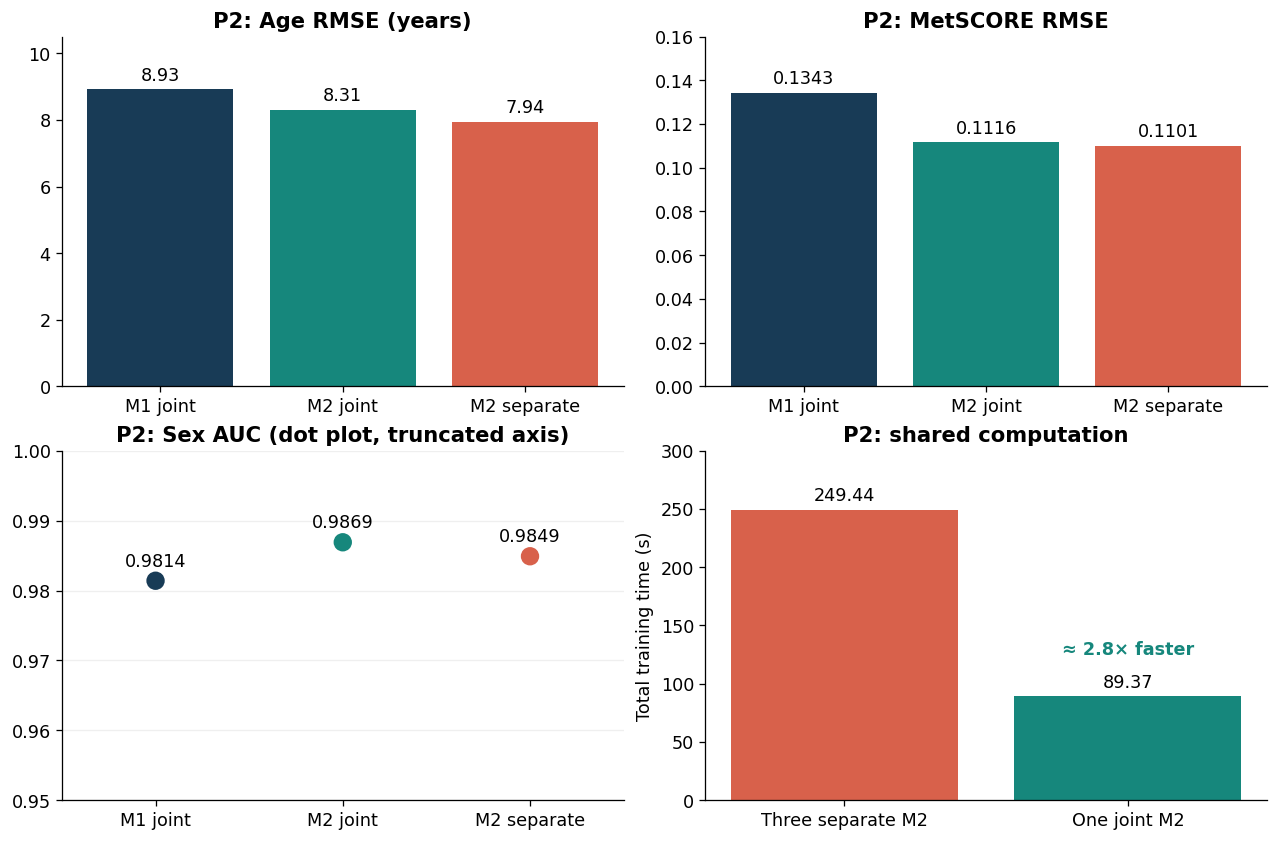

In [24]:
# REPORTED values only (P2, Tables 1-3).
labels = ["M1 joint","M2 joint","M2 separate"]
panels = [("Age RMSE (years)", [8.9306,8.3061,7.9438], (0,10.5), "%.2f"),
          ("MetSCORE RMSE", [0.1343,0.1116,0.1101], (0,.16), "%.4f"),
          ("Sex AUC", [0.9814,0.9869,0.9849], (.95,1.0), "%.4f")]
fig, axes = plt.subplots(2,2,figsize=(11,7.2),layout="constrained")
for ax, (title, vals, ylim, fmt) in zip(axes.flat, panels):
    if ylim[0] > 0:   # truncated axis: a dot plot, so that bar heights do not exaggerate differences
        ax.scatter(labels, vals, s=110, color=[NAVY,TEAL,CORAL], zorder=3)
        for i, v in enumerate(vals):
            ax.annotate(fmt % v, (i, v), xytext=(0, 9), textcoords="offset points", ha="center")
        ax.set(ylim=ylim, xlim=(-.5, 2.5), title=f"P2: {title} (dot plot, truncated axis)")
        ax.grid(axis="y", alpha=.2)
        continue
    ax.bar(labels, vals, color=[NAVY,TEAL,CORAL]); ax.set(ylim=ylim, title=f"P2: {title}")
    ax.bar_label(ax.containers[0], fmt=fmt, padding=3)
ax = axes[1,1]
ax.bar(["Three separate M2","One joint M2"],[249.44,89.3678],color=[CORAL,TEAL])
ax.bar_label(ax.containers[0], fmt="%.2f", padding=3)
ax.set(ylabel="Total training time (s)", ylim=(0,300), title="P2: shared computation")
ax.text(1, 125, "≈ 2.8× faster", ha="center", color=TEAL, weight="bold")
finish(fig,"10_p2_results")

### REPORTED [P2, §3.4, pp. 15–16] · The biology in P2's explanations

| Output | Features P2 discusses (Fig. 2, pp. 15–16) | P2's biological reading | What it does not establish |
|---|---|---|---|
| Age | Albumin (ranked 1st in Fig. 2), 3-hydroxyisobutyrate, glucose, anhydrosorbitol, LDL, urea; ESR ranks 7th | A multi-systemic signature: chronic inflammation (albumin, ESR); a valine catabolite linked to insulin resistance with glucose and anhydrosorbitol; organ function and lipids (urea, LDL) | That these markers cause aging |
| MetSCORE | Glucose, then HDL and LDL | Matches the clinical definition of metabolic syndrome, driven by hyperglycemia and dyslipidemia | Independent validation: MetSCORE is itself built from blood biomarkers |
| Sex | Erythrocyte counts, creatine/creatinine, urate, glycerol, SPC | Known dimorphisms: red-cell counts, muscle mass (creatinine), adipose distribution and hormonal profiles | A model of sex or gender beyond the recorded binary label |

In both architectures the direction of the dominant contributions agrees. **Cross-paper consistency:** albumin leads both P1's clock and P2's age model, and ESR is among the top ten features of both (P2, Fig. 2, p. 15), on related serum-NMR data with different learners.


<div style="border-left:6px solid #16877c;background:#eef7f5;color:#1d3540;padding:12px 20px;border-radius:8px;margin:16px 0">

<span style="color:#16877c;font-weight:700;letter-spacing:1.5px;font-size:12px">MAIN CONCLUSION</span> **P2**

**Theory.** Any attribution obeying the four Shapley axioms in $\mathbb R^m$ must be coordinate-wise (Thm 2.8, Cor. 2.10), so per-output SHAP is a theorem, not a convention, and it is stable under perturbations of the model (Props 2.11, 2.13).

**Practice.** One shared M2 trains about 2.8× faster than three separate models, beats the linear baseline, matches separate models on MetSCORE and sex, and gives explanations that agree with separate models (cosine ≥ 0.974). [P2, Tables 1–4]

*Scope:* the dedicated age model is slightly more accurate (RMSE 7.94 vs 8.31 y); whether shared representations capture more biology is an open, testable question.

</div>

<div style="background:#123047;color:white;padding:12px 20px;border-radius:8px;margin:28px 0 8px"><span style="color:#83d9c4;letter-spacing:2px;font-size:13px;font-weight:700">PART VI · INTERPRETATION FOR PRACTITIONERS</span><span style="color:#e4eef3"> — from a model explanation to a research or clinical question</span></div>

<a id="practice"></a>
## 11 · From a model explanation to a practitioner's interpretation

*Why this is exciting:* distortion maps separate renal, inflammatory and metabolic aging [P1, p. 11], a natural starting point for organ-specific clocks (proposal; multi-organ clocks are discussed in P2, §1.2).

| Observation (source) | Interpretation supported by the analysis | What it does not establish |
|---|---|---|
| Albumin and ESR have the largest mean \|SHAP\|: 3.1 and 2.4 y; inflammation is the top group (16.9%) [P1, p. 7, Fig. 3] | Chronic inflammation (inflammaging) is central to the clock's learned signal; albumin and ESR are time-integrated readouts [P1, p. 10] | The number of life-years caused or lost by a biomarker |
| All 11 disease cohorts are right-shifted; controls are not [P1, Fig. 4] | Disease-associated metabolic changes resemble different aspects of the reference age pattern | A universal rate of aging, or individual diagnosis |
| Three axes of distortion: renal, inflammatory, metabolic [P1, Fig. 5, p. 11] | Diseases accelerate the clock through distinct, biologically coherent pathways | That the axes are causal or complete |
| Acute infections show pronounced inflammatory shifts; in long COVID glutamate and glucose dominate [P1, pp. 10–11] | The clock responds to current physiology as well as to age-associated patterns | Permanent acceleration of an underlying aging process |
| CKD: negative creatinine SHAP difference (a “false rejuvenator”); CVD: elevated eGFR also lowers predicted age [P1, pp. 9, 11] | A marker can change meaning between the reference and a disease context | That pathological creatinine retention is rejuvenation |
| Later CVD events: about 8 y of acceleration beforehand (n = 59) [P1, pp. 9, 11] | A promising signal for prospective evaluation | Calibrated individual event risk, or value beyond standard scores |
| IBD remission: about 3 y less distortion than active disease [P1, p. 8] | Compatible with state dependence and partial recovery (allostasis) | A randomized treatment effect or within-person reversal |
| Joint and separate models give aligned explanations for age, MetSCORE and sex [P2, Table 4] | A shared model can be explained output by output without losing interpretability | Identical local explanations for every participant |

P1's pathway aggregation uses attribution magnitudes, and its disease PCA uses |SHAP| (Fig. 5); distinguish these from signed disease–reference differences. Pathway group definitions are given in P1's Extended Data Table 22.


<div style="border-left:6px solid #6b7c86;background:#f4f6f7;color:#1d3540;padding:12px 20px;border-radius:8px;margin:16px 0">

<span style="color:#6b7c86;font-weight:700;letter-spacing:1.5px;font-size:12px">DISCUSS</span> **Discussion case**

A researcher sees a +8-year distortion and a large positive inflammation contribution in a 60-year-old donor sampled during illness. A defensible description is: “This profile appears older than expected under our reference clock, and the prediction is largely associated with inflammatory measurements.” Good next steps are assay checks, contextual metadata, repeat sampling after recovery and comparison with independent outcomes. Neither “the donor has lost eight years of life” nor “lowering this marker will reverse aging” follows from SHAP.

</div>

### Interactive window · What changes when the profile changes?

The slider perturbs the same synthetic inflammation-related measurements as the domain-shift lab in section 6. The right panel shows the change in **model attribution** relative to the unperturbed profile. This is a sensitivity experiment, not a simulated treatment effect. (Static preview at offset 1.0; the slider is live in a running kernel.)

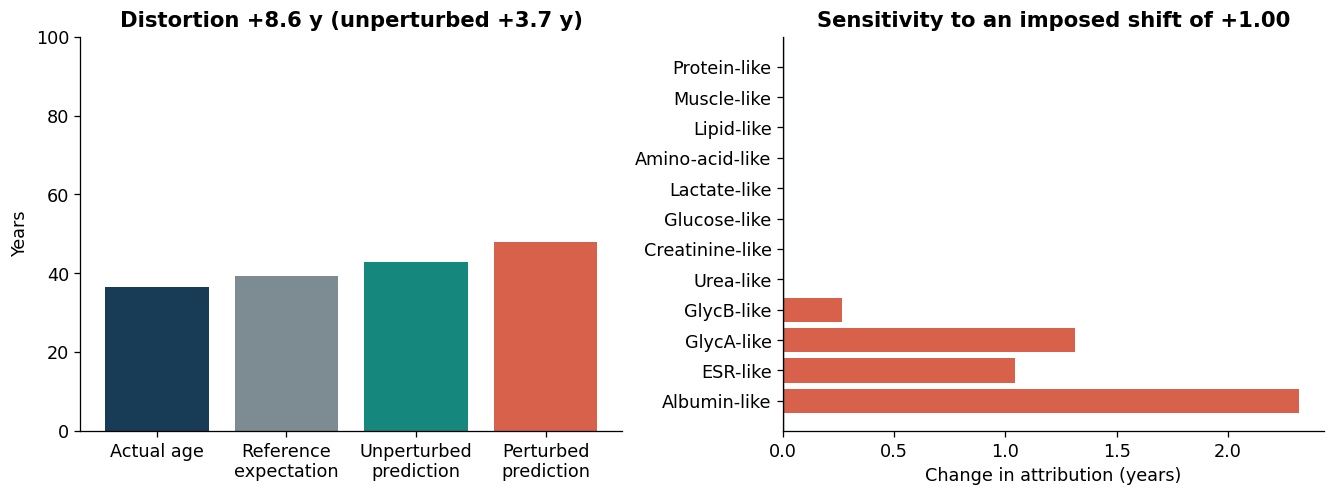

In [25]:
def profile_figure(offset=1.0):
    row = Xte.iloc[[person]]
    shifted = shift_features(row,offset)
    zs = preprocessor.transform(shifted)
    ps = float(clock.predict(shifted)[0])
    phis = (zs[0]-background_mean)*linear_model.coef_
    delta = phis-phi_test[person]
    fig, axes = plt.subplots(1,2,figsize=(11.5,4.2),layout="constrained")
    values = [float(ate.iloc[person]),float(expected_test[person]),float(pred[person]),ps]
    axes[0].bar(["Actual age","Reference\nexpectation","Unperturbed\nprediction","Perturbed\nprediction"],
                values,color=[NAVY,GREY,TEAL,CORAL])
    axes[0].set(ylabel="Years",ylim=(0,100),
                title=f"Distortion {ps-expected_test[person]:+.1f} y (unperturbed {pred[person]-expected_test[person]:+.1f} y)")
    axes[1].barh(X.columns,delta,color=[CORAL if d>=0 else TEAL for d in delta])
    axes[1].axvline(0,color=NAVY)
    axes[1].set(xlabel="Change in attribution (years)",title=f"Sensitivity to an imposed shift of {offset:+.2f}")
    return fig

controls = ({"offset": widgets.FloatSlider(value=1.0, min=-1, max=2, step=.25, description="Offset",
                                           continuous_update=False)} if HAS_WIDGETS else None)
live_window(profile_figure, controls, offset=1.0)

### What should accompany a clock result in a research report?

A frozen model version and a specified reference population; raw age gap and adjusted distortion with their definitions; which variables are measured and which inferred; the uncertainty and its target; support relative to the training data; and the sign, units and background of each explanation. Age range, sex, ancestry, assay, medication and disease context can all affect applicability.

**From association to utility:** test whether the clock adds to a prespecified age-and-clinical-covariate model for future outcomes, with appropriate follow-up and censoring methods, external calibration and a decision-relevant endpoint. A group difference or a significant K–S test is a starting point; individual utility requires a different evaluation.


<div style="border-left:6px solid #16877c;background:#eef7f5;color:#1d3540;padding:12px 20px;border-radius:8px;margin:16px 0">

<span style="color:#16877c;font-weight:700;letter-spacing:1.5px;font-size:12px">MAIN CONCLUSION</span> **For practitioners**

A metabolic clock is a contextual molecular readout with a rich explanatory profile: it points to *which physiological axis* is distorted, which is exactly what makes it useful for generating hypotheses. A feature contribution is a reason to investigate, not an intervention prescription.

</div>

<div style="background:#123047;color:white;padding:12px 20px;border-radius:8px;margin:28px 0 8px"><span style="color:#83d9c4;letter-spacing:2px;font-size:13px;font-weight:700">PART VII · TAKE-HOME MESSAGE AND PERSPECTIVES</span><span style="color:#e4eef3"> — what to remember, and what to do next</span></div>

<a id="takehome"></a>
## 12 · The take-home messages

<div style="border-left:6px solid #16877c;background:#eef7f5;color:#1d3540;padding:12px 20px;border-radius:8px;margin:16px 0">

<span style="color:#16877c;font-weight:700;letter-spacing:1.5px;font-size:12px">MAIN CONCLUSION</span> **1 · Serum NMR is a scalable window on aging**

75 curated NMR-derived biomarkers predict age with r = 0.88 over 7–106 years, in one model for both sexes, and transfer to an independent laboratory with moderately larger error. [P1]

</div>

<div style="border-left:6px solid #16877c;background:#eef7f5;color:#1d3540;padding:12px 20px;border-radius:8px;margin:16px 0">

<span style="color:#16877c;font-weight:700;letter-spacing:1.5px;font-size:12px">MAIN CONCLUSION</span> **2 · Interpretability is a design choice with a measurable price**

From spectral bins (κ ≈ 15,000) to curated biomarkers (κ ≈ 16) for about 2 years of RMSE, giving stable, biologically coherent SHAP profiles led by inflammation. Conditioning is where numerical analysis meets biochemistry. [P1]

</div>

<div style="border-left:6px solid #16877c;background:#eef7f5;color:#1d3540;padding:12px 20px;border-radius:8px;margin:16px 0">

<span style="color:#16877c;font-weight:700;letter-spacing:1.5px;font-size:12px">MAIN CONCLUSION</span> **3 · Distortion maps reveal disease-specific aging**

Renal, inflammatory and metabolic axes; early signals before cardiovascular events; partial reversal in remission. Reading age gaps correctly requires a reference: even the best clock has slope $R^2<1$. *Scope:* associations; prospective utility is next. [P1; section 3]

</div>

<div style="border-left:6px solid #16877c;background:#eef7f5;color:#1d3540;padding:12px 20px;border-radius:8px;margin:16px 0">

<span style="color:#16877c;font-weight:700;letter-spacing:1.5px;font-size:12px">MAIN CONCLUSION</span> **4 · The rigidity theorem**

Under the Shapley axioms, multi-output explanation is necessarily per output. So a shared model, which in P2 trained 2.79× faster, can still be explained output by output; in P2 these explanations agree with those of separately trained models. Other notions of fairness may allow coupling (P2's open problem 1). [P2]

</div>

<div style="border-left:6px solid #16877c;background:#eef7f5;color:#1d3540;padding:12px 20px;border-radius:8px;margin:16px 0">

<span style="color:#16877c;font-weight:700;letter-spacing:1.5px;font-size:12px">MAIN CONCLUSION</span> **5 · The next breakthroughs are joint**

Longitudinal and diverse cohorts, multi-omics and organ-specific clocks on the biological side; dynamic, correlation-aware and certified explanation theory on the mathematical side. See the [perspectives](#research).

</div>

**Questions to bring to the other community.**
*Geneticists and experimentalists* can ask: what was measured, what was inferred, what context changes the meaning, and what experiment could challenge the explanation? *Mathematicians* can ask: what target is identified, what distribution is assumed, what norm controls stability, which axioms define the allocation, and which guarantee survives estimation and distribution shift?

**Exit question:** what single new dataset or theorem would most increase your confidence that a metabolic clock captures useful biology?

<a id="research"></a>
## 13 · Perspectives for further research

*Why this is exciting:* every open problem here needs both communities.

**P1 names its own next steps (p. 11):** validation in more diverse populations (its cohort is predominantly Caucasian), longitudinal data to capture temporal dynamics, and additional omics layers.


<div style="border-left:6px solid #2d6a4f;background:#edf6f0;color:#1d3540;padding:12px 20px;border-radius:8px;margin:16px 0">

<span style="color:#2d6a4f;font-weight:700;letter-spacing:1.5px;font-size:12px">PERSPECTIVE</span> **REPORTED [P2, §4, pp. 16–18] · Five open problems for mathematicians**

1. **Beyond the Shapley axioms:** attribution rules that capture joint dependencies or interactions between outputs.
2. **Exploiting output correlations in estimation:** shared sampling, variance reduction and new approximation schemes for vector SHAP.
3. **Pareto structure:** multi-output training as multi-objective optimization (a weak Pareto-optimal search, App. B.3); can Pareto principles inform or constrain explanations?
4. **Dynamic SHAP** for recurrent or time-dependent predictors, consistent with efficiency and additivity, a bridge between explainability and **control theory**.
5. **Efficient computation in high dimensions:** axiom-preserving reduced-order, sampling or variational approximations with rigorous error bounds, extending the spectral approach of Morales, arXiv:2511.00185 (P2 ref. [22]) to vector outputs.

P2's stated limitations (p. 17): it characterizes existing attribution rather than proposing a new method; the rigidity theorem assumes the classical axioms in full strength; and the framework does not encode domain-specific semantics.

</div>

<div style="border-left:6px solid #2d6a4f;background:#edf6f0;color:#1d3540;padding:12px 20px;border-radius:8px;margin:16px 0">

<span style="color:#2d6a4f;font-weight:700;letter-spacing:1.5px;font-size:12px">PERSPECTIVE</span> **For genetics, metabolomics and clinical biology**

(a) Diverse, multi-ancestry reference cohorts [P1, p. 11], with harmonized NMR acquisition across laboratories (proposal). (b) Longitudinal sampling to separate trait from state, for example through illness and recovery (the IBD remission signal) [P1, pp. 8, 11]. (c) Multi-omics on the same samples (genotype, methylation, proteomics); clock-GWAS and Mendelian randomization under stated assumptions [P1, p. 11; proposal]. (d) Organ-specific clocks along the renal, inflammatory and hepatic-metabolic axes (proposal; axes: P1, p. 11; multi-organ clocks: P2, §1.2). (e) Prospective outcome studies beyond the CVD cohort, and context-aware reading of false rejuvenators across disease states.

</div>

<div style="border-left:6px solid #2d6a4f;background:#edf6f0;color:#1d3540;padding:12px 20px;border-radius:8px;margin:16px 0">

<span style="color:#2d6a4f;font-weight:700;letter-spacing:1.5px;font-size:12px">PERSPECTIVE</span> **For mathematics**

(a)–(e) P2's five open problems above. (f) Is disease distortion a low-dimensional signature space? Geometry of SHAP-profile embeddings and stability of the clustering behind P1's three axes. (g) Context-aware or disease-conditional attribution that detects false rejuvenators (conditional games, out-of-support detection). (h) Identifiability of a latent aging state; conformal and optimal-transport guarantees under laboratory shift; equivalence testing for external validation (proposals).

</div>

### Joint projects

| Joint question | Biology / genetics contribution | Mathematical contribution | First deliverable | Extends |
|---|---|---|---|---|
| **Trait or transient state?** | Repeated samples; illness/recovery metadata; functional outcomes | State-space or mixed-effects models; dynamic SHAP | Within-person, technical and between-person variance before interpreting slopes | P1 p. 11; P2-4 |
| **Which pathways are reproducible across laboratories?** | Prespecified groups; replicate assays; orthogonal measurements | Whole-pipeline bootstrap; conditional-game sensitivity; grouped games | A pathway stability report across laboratories and backgrounds | P2-2, P2-5 |
| **When does joint training help?** | Tasks with biological rationale and reliable labels (e.g. organ-specific ages) | Loss scaling; gradient conflict; Pareto fronts | A multi-seed benchmark reporting each task | P2-3 |
| **From attribution to intervention hypothesis** | Mechanistic assays; perturbation and intervention designs | Explicit causal models and identifiable estimands | One testable pathway hypothesis with an independent endpoint | P1 p. 11 |
| **Who is underserved by the reference?** | Diverse recruitment; standardized acquisition | Transport diagnostics; subgroup calibration | A preregistered external validation with cohort-level intervals | P1 p. 11 |

### A dynamic formulation (links P1's longitudinal agenda to P2's open problem 4)

$$B_i(t+\Delta)=F_\theta(B_i(t),U_i(t),\Delta)+\eta_i(t),\qquad
X_i(t)=H_\psi(B_i(t),C_i(t))+\epsilon_i(t).$$
Here $B$ is a latent state, $U$ an exposure or intervention, $C$ the measurement context and $\eta,\epsilon$ process and measurement noise. Longitudinal data help separate state from noise but do not identify $B$ or an intervention effect without constraints and suitable design. Explaining $F_\theta$ over time is exactly the “dynamic SHAP” problem, where explainability meets control theory. An organ-specific vector may ultimately be more informative than a single age.

**Genetic evidence needs its own design.** A high SHAP ranking does not establish a genetic mechanism. Family structure, population structure, pleiotropy and selection must be addressed when genetic data are introduced; genetic-instrument or intervention analyses need their own identification assumptions.

### A feasible first collaboration

1. Agree on one endpoint, one intended population and one reference definition; draw the hypothesized biology before training.
2. Assemble repeated measurements and an external cohort; document assay provenance and upstream predictor training.
3. Freeze a simple baseline, preprocessing, task weights and explanation background; reserve the external cohort.
4. Evaluate accuracy, biological endpoint validity, uncertainty and explanation stability separately.
5. Turn one stable pathway association into a falsifiable experimental hypothesis and a follow-up measurement plan.


<div style="border-left:6px solid #9a6a12;background:#fbf4e6;color:#1d3540;padding:12px 20px;border-radius:8px;margin:16px 0">

<span style="color:#9a6a12;font-weight:700;letter-spacing:1.5px;font-size:12px">OPPORTUNITY</span> **The opportunity**

Models can organize molecular measurements into hypotheses that biological expertise can challenge, and biological knowledge can shape representations and pose new mathematical questions. P1 and P2 show both directions of this exchange already producing results.

</div>

<div style="background:#123047;color:white;padding:12px 20px;border-radius:8px;margin:28px 0 8px"><span style="color:#83d9c4;letter-spacing:2px;font-size:13px;font-weight:700">APPENDIX</span><span style="color:#e4eef3"> — exercises, sources, software and vocabulary</span></div>

<a id="exercises"></a>
## 14 · Exercises and discussion prompts

### Master's level

**E1 · Correlation is not agreement (10 min).** Add 15 years to every test prediction. Recompute Pearson $r$, RMSE and mean error. Explain why one metric stays unchanged.

**E2 · Reference choice (15 min).** Refit the reference line using only the younger half of the calibration cohort. Inspect older test participants. Why is the resulting distortion an extrapolation problem?

**E3 · Cancellation (10 min).** Construct two pathway contributions of opposite sign. Compare the signed group sum, the sum of magnitudes and the absolute value of the group sum. Which can reconstruct a prediction? Which does P1 use for pathway magnitude?

**E4 · Proxy credit (15 min).** Derive the general conditional attribution $\phi=(x_1-\rho x_2/2,\rho x_2/2)$ for $f(x)=x_1$, then plot it against $\rho\in[0,0.95]$ for $x=(2,2)$ and $x=(2,-2)$. Explain why the unused feature is not a dummy in the conditional game.

### Doctoral level

**E5 · The axioms do real work (20 min).** Show that the `leaky` rule of section 9 is efficient, symmetric and linear. Prove the allocation for a unanimity basis game using symmetry and the dummy axiom, and extend by additivity.

**E6 · Two kinds of stability (30 min).** Bootstrap the full synthetic clock and compare prediction variability, individual-feature attribution variability and signed group variability. Keep one evaluation panel and one background fixed; then vary the background separately.

**E7 · A fair joint-learning benchmark (30–45 min).** Repeat the two-task experiment across five seeds, compare useful and noisy auxiliary targets, and normalize task losses. Report per-task uncertainty, runtime, parameter counts and negative transfer. Which findings are empirical, and which follow from P2's theorem?

**E8 · The age-gap theorem (20 min).** Prove $\operatorname{Cov}(G,f^*)=0$ and $\operatorname{Cov}(G,A)=-(1-R^2)\operatorname{Var}(A)$. Verify them in the lab with an ExtraTrees clock.

**E9 · Design a biological validation (discussion).** Specify an independent longitudinal endpoint, inclusion criteria, sample timing, confounders, family/cohort splits and a primary analysis comparing a baseline model with and without the clock. State which result would falsify the usefulness of the score.

<details><summary><strong>Instructor hints / short answers</strong></summary>

E1: Pearson correlation is translation invariant. The mean error shifts by 15; RMSE rises and must be recomputed. E2: residualization is reference-dependent and can fail outside its fitted age support. E3: for (+4,−4) the three summaries are 0, 8 and 0; signed sums reconstruct, whereas P1 reports summed magnitudes. E4: $v(\{2\})=\mathbb E[X_1\mid X_2=x_2]=\rho x_2$; the proxy reveals information about the used feature, and gets negative credit when $x_2<0$. E5: off-coordinate allocations can cancel across players, so efficiency survives; the dummy player of $u_Te_1$ receives a nonzero vector. E6: good prediction stability need not imply unique feature allocation. E7: the theorem concerns a fixed game's allocation, not learning superiority. E8: use the tower property; the slope identity holds approximately for a near-optimal learner. E9: endpoints used to construct an auxiliary score are not independent validation of that score.

</details>

<a id="references"></a>
## 15 · Sources, software and a shared vocabulary

### Primary sources and exact locations

| Label | Source | Where to look |
|---|---|---|
| P1 | [*Mapping metabolic aging and disease-associated acceleration using an interpretable NMR-based clock*](MetAgePaper_submitted.pdf) | pp. 2–6 motivation, cohorts, representations, external validation, sex; Fig. 3 (p. 7) grouped SHAP; Fig. 4 (p. 8) disease distortion; pp. 9–11 signatures, PCA axes, limitations, future work; pp. 12–14 methods and data availability |
| P2 | [*Fair feature attribution for multi-output prediction: a Shapley-based perspective*](SHAP_SIMODS_03.pdf) | Def. 2.3, 2.7; Thms 2.8–2.9; Cor. 2.10; Props 2.11–2.13; Tables 1–4; §4 open problems; App. A proofs (pp. 19–22); App. B correlation and Pareto (pp. 22–25) |
| Companion code | [DCN-FAU-AvH/SHAP-multi-output](https://github.com/DCN-FAU-AvH/SHAP-multi-output) (P2 ref. [13]) | P2 states (p. 11) that code and data reproducing its example are there. When checked on 29 September 2026, the main branch contained a synthetic complete-blood-count (HCT/HGB/RBC; 30,000 synthetic samples) demonstration of the same multi-output SHAP pipeline, with linear and nonlinear notebooks; please verify the current release; reproducing Tables 1–4 exactly needs the study data and the matching release. |
| MetSCORE | Gil-Redondo, R. et al., *MetSCORE: a molecular metric to evaluate the risk of metabolic syndrome based on serum NMR metabolomics*, Cardiovasc. Diabetol. 23 (2024) | Cited as P1 ref. 11 and P2 ref. [12] |
| Conformal prediction | [Angelopoulos & Bates, *A Gentle Introduction to Conformal Prediction…*](https://arxiv.org/abs/2107.07511) | Background for section 6; not a result of P1 or P2 |

**Affiliations behind the joint venture.** P2: DeustoTech–University of Deusto (Bilbao), FAU Erlangen-Nürnberg (Chair for Dynamics, Control, Machine Learning and Numerics), Universidad Autónoma de Madrid, ATLAS Molecular Pharma, CIC bioGUNE (Precision Medicine and Metabolism Laboratory) and CIBERehd. P1 adds a multi-national clinical consortium from Spain, Portugal, Italy, Austria, the UK, Norway, Germany, Brazil and the USA.

### Software toolkit in this notebook

| Function | What it does | Section |
|---|---|---|
| `simulate_cohort(n, seed)` | Synthetic correlated marker cohort, no patient data | 5 |
| `shift_features(frame, amount)` | Simulated laboratory offset | 6 |
| split-conformal block | 90% interval for chronological age | 6 |
| `exact_shapley(game)` | Exact scalar or vector Shapley values from all $2^p$ coalitions | 8 |
| `linear_gaussian_game(B, x, Σ, conditional)` | Closed-form conditional or marginal games for linear models (P2, App. B) | 8 |
| `harsanyi_dividends(game)` | Möbius inversion; grouped-game comparison | 8 |
| `leaky(v)` | A counterexample rule: output 1 untouched, a zero-sum term derived from output 1 added to output 2; efficient, symmetric and linear, but breaks the dummy axiom | 9 |
| `multi_output_figure(ρ, conditional)` | Interactive rigidity-theorem explorer | 9 |
| `live_window(make_figure, controls, …)` | Static figure that becomes interactive in a live kernel | setup |

This is exponential-cost teaching code: for real models use SHAP's Linear/Tree/DeepExplainer and validate them against these exact small games. **Documentation:** [scikit-learn pitfalls](https://scikit-learn.org/stable/common_pitfalls.html) · [SHAP LinearExplainer](https://shap.readthedocs.io/en/latest/generated/shap.LinearExplainer.html) · [SHAP TreeExplainer](https://shap.readthedocs.io/en/latest/generated/shap.TreeExplainer.html). The notebook does not download or execute the authors' code. `data/source_manifest.json` identifies the manuscript versions used by SHA-256 hash; generated plots, videos and simulations are original teaching material, and P1 Figure 2 is reproduced from [P1] with credit.

### Glossary for the two communities

| Term | Working meaning in this lesson |
|---|---|
| Metabolomics | Measurement of small molecules that reflect metabolic processes and context |
| NMR, NOESY, CPMG, J-resolved | Nuclear magnetic resonance spectroscopy; a broad 1D acquisition; a 1D acquisition that attenuates macromolecules; a 2D acquisition that resolves overlapping peaks |
| FID | Free-induction decay: the raw time-domain NMR signal before the Fourier transform |
| IVDr | Standardized, automated in-vitro-diagnostic NMR quantification reports (metabolites, lipoproteins) |
| GlycA / GlycB, SPC | NMR inflammation signals from glycoproteins; supramolecular phospholipid composite |
| ESR | Erythrocyte sedimentation rate; an inflammation-related clinical measurement |
| eGFR | Estimated glomerular filtration rate; a derived renal-function estimate |
| Cohort codes | CKD kidney disease · PRC prostate cancer · MetS metabolic syndrome · MASLD steatotic liver disease · IBD inflammatory bowel disease · PSO psoriasis · CVD cardiovascular events · ALS amyotrophic lateral sclerosis · FLU influenza · COV COVID-19 · LCOV long COVID · ITCL / ETCL internal / external controls |
| MetSCORE | Serum-NMR metabolic-syndrome risk metric (Gil-Redondo et al. 2024); a P2 target, not our synthetic score |
| Metabolic distortion | Deviation of the clock from the reference regression line of predicted on chronological age |
| TPOT | An AutoML framework that searches machine-learning pipelines |
| Ridge / ExtraTrees / MLP | $\ell_2$-penalized least squares / randomized tree ensemble / feedforward neural network |
| Condition number κ | $\sigma_{max}/\sigma_{min}$ of the feature matrix; measures error amplification |
| K–S test | Kolmogorov–Smirnov test comparing two whole distributions |
| Conformal interval, exchangeability | Distribution-free prediction band; the symmetry assumption behind its guarantee |
| SHAP / Shapley value | Allocation of a specified coalition game's prediction difference |
| Beeswarm | SHAP summary plot: one dot per sample and feature, coloured by feature value |
| Background / reference | Distribution that defines the baseline and what “missing” features mean |
| DeepExplainer | An approximate SHAP algorithm for neural networks using background samples |
| Harsanyi dividend | The pure synergy of a coalition; Shapley values split each dividend equally |
| Domain shift | Change in the data-generating or measurement distribution |
| Identifiability | Whether the target quantity is determined by observations plus assumptions |
| Negative transfer | Joint learning harms a task relative to a suitable separate model |
| Pareto trade-off | Improving one objective can require worsening another |

In [26]:
# Appendix · automated checks. These validate the teaching calculations, not the papers.
assert np.isfinite(pred).all()
assert len(train_ids)+len(cal_ids)+len(test_ids) == len(X)
assert len(set(train_ids)|set(cal_ids)|set(test_ids)) == len(X)            # with the sizes: disjoint
assert k_conf == math.ceil((len(scores)+1)*(1-alpha)) and q == np.sort(scores)[k_conf-1]   # conformal rule
assert abs(beta_ref - r2_score(acal, pred_cal)) < .05                          # slope ≈ R² (section 3)
assert np.allclose(conditional_phi, [x2[0]-rho*x2[1]/2, rho*x2[1]/2])          # proxy closed form
assert np.allclose(baseline+phi_test.sum(axis=1),pred)                         # efficiency, clock
assert np.allclose(phi_vector,phi_separate)                                    # coordinate-wise rule
assert np.allclose(phi_vector.sum(axis=0),game[-1])                            # vector efficiency
assert allocation_distance <= 2*game_distance+1e-12                            # stability bound
print("All teaching checks passed: disjoint splits, conformal rule, slope ≈ R², closed forms, "
      "exact allocations, stability bound.")

def _version(package):
    try:
        return metadata.version(package)
    except metadata.PackageNotFoundError:
        return "not installed"
display(pd.Series({p: _version(p) for p in ["numpy", "pandas", "matplotlib", "scikit-learn", "ipywidgets"]},
                  name="Version used").to_frame())

All teaching checks passed: disjoint splits, conformal rule, slope ≈ R², closed forms, exact allocations, stability bound.


,Version used
numpy,2.2.0
pandas,2.2.3
matplotlib,3.10.0
scikit-learn,1.6.1
ipywidgets,8.1.7


[Return to the beginning](#top)